# Classificação Compra / Lateral / Venda — mini-índice (WIN), M5

## O que eu quero fazer aqui

A ideia é simples de enunciar: **olhar para o que o mini-índice fez entre 09:00 e 10:59 e
tentar adivinhar o que ele vai fazer entre 11:00 e 11:59.** A resposta é uma de três
classes — Compra, Venda ou Lateral.

Se isso funcionar, a operação é direta: entro às 11:00 e saio às 12:00. Se o modelo disse
Compra, compro. Se disse Venda, vendo. Se disse Lateral, fico de fora e não pago custo
nenhum.

## Por que esses horários

Escolhi essa janela por causa de dois momentos que concentram quase toda a energia do
pregão brasileiro:

**A abertura, das 09:00 às 10:00.** É o momento mais volátil do dia. O preço de abertura
sai do leilão e, quando o mercado começa a girar, tudo que aconteceu desde o fechamento
anterior é digerido de uma vez. Spread largo, movimento rápido, volume altíssimo. É aqui
que compradores e vendedores brigam para definir a direção do dia.

**A abertura americana, às 11:30.** O Ibovespa é fortemente correlacionado com o S&P 500.
Quando Nova York abre, entra uma injeção nova de volume e volatilidade no nosso mercado —
e o que os americanos fazem na primeira hora costuma arrastar o mini-índice junto. Muito
operador espera exatamente esse momento para confirmar posição.

A janela das 11:00 fica no meio desses dois eventos. É o período em que o mercado já
mostrou a cara na abertura e ainda está se posicionando para o que vem de Nova York.

---

## A janela que escolhi: 09:00–10:59 → 11:00–11:59

Antes de fixar essa configuração eu testei sete combinações diferentes de janela de
entrada e janela-alvo. **O teste rodou apenas nos primeiros 80% dos dias**, deixando os
250 dias finais intocados — se eu usasse a base inteira para escolher a janela, o holdout
já nasceria contaminado.

Para a comparação ser justa entre janelas de tamanhos diferentes, usei rótulo por tercis
(quantis móveis, só com dados passados). Isso deixa as classes equilibradas por
construção e mantém o baseline sempre perto de 1/3.

| Entrada | Alvo | n | Baseline | Modelo | Ganho | dp entre folds |
|---|---|---|---|---|---|---|
| **09:00–10:59** | **11:00–11:59** | 893 | 0,322 | 0,361 | **+0,039** | 0,039 |
| 09:00–11:29 | 11:30–12:29 | 893 | 0,349 | 0,355 | +0,007 | 0,060 |
| 10:00–10:59 | 11:00–11:59 | 877 | 0,322 | 0,340 | +0,018 | 0,064 |
| 09:00–09:59 | 10:00–10:59 | 870 | 0,337 | 0,310 | −0,026 | 0,044 |
| 09:00–10:59 | 11:00–12:59 | 893 | 0,350 | 0,353 | +0,003 | 0,048 |
| 09:00–11:59 | 12:00–12:59 | 893 | 0,292 | 0,343 | +0,051 | 0,085 |
| 09:00–10:59 | 15:00–15:59 | 893 | 0,361 | 0,311 | −0,050 | 0,021 |

Olhando essa tabela, a tentação é pegar a linha de maior ganho (+0,051) e declarar
vencedora. **Não vou fazer isso, e a razão é aritmética.**

Os sete ganhos têm média +0,006 e desvio-padrão 0,033. Se todos forem ruído em torno de
zero, o máximo esperado de sete sorteios é mais ou menos 0,033 × 1,35 ≈ **+0,045**. O
maior valor que eu observei foi +0,051. Ou seja: está exatamente onde o acaso colocaria.
Escolher a janela por esse critério seria escolher o sorteio mais sortudo.

Repare também que em **todas** as linhas o desvio-padrão entre folds é do mesmo tamanho
ou maior que o próprio ganho. Nenhuma configuração é estável.

A última linha é um controle que eu coloquei de propósito: tentar prever as 15:00–15:59 a
partir da manhã. Deu −0,050, como tem que dar. Isso me diz que o arcabouço de teste
detecta corretamente a ausência de sinal — os outros números não são artefato de código
quebrado.

**Então por que 09:00–10:59 → 11:00–11:59?** Por quatro motivos que não dependem do
resultado:

1. **É a configuração original do projeto.** Trocar depois de ver os números seria
   garimpar dado.
2. **É a mais estável entre as que deram ganho positivo** — desvio de 0,039 entre folds,
   contra 0,085 da alternativa de maior ganho.
3. **Preserva a tese econômica**: entro às 11:00, saio às 12:00, com a janela de entrada
   fechando imediatamente antes.
4. **Maximiza a amostra** — 1.220 dias na base completa.

---

## O holdout: 09:00–11:59 → 12:00–12:59

Guardei os **244 dias finais** (2025-08-18 a 2026-08-12) sem tocar. Eles não entraram no
teste de janelas, não entraram na escolha de features, não entraram em nada.

Quando chegar a hora de abrir, vou testar **09:00–11:59 → 12:00–12:59**.

**E não é porque foi a de maior ganho no sweep** — é porque é a única alternativa que tem
uma justificativa causal independente do resultado. Nessa configuração a janela de
entrada **inclui as 11:30**, ou seja, o modelo enxerga a reação do mercado à abertura
americana antes de ter que prever. Se o mecanismo que eu descrevi lá em cima for real,
é aqui que ele deveria aparecer.

Se der positivo, eu consigo explicar por quê. Nas outras janelas, um resultado positivo
seria só sorte com uma história inventada por cima.

> **A regra que eu me imponho:** o holdout aceita **uma** configuração, escolhida antes de
> abrir. Se eu abrir, não gostar do resultado, ajustar alguma coisa e abrir de novo, ele
> deixa de ser holdout e vira treino disfarçado. A flag `EXECUTAR_HOLDOUT` fica em `False`
> justamente para eu não fazer isso por distração.


---

# Como conectar as velas na rede: duas ideias

Antes de sair treinando, vale pensar em como os dados de cada vela devem entrar na rede.
Existem duas formas bem diferentes de montar isso, e elas levam a modelos com capacidades
muito distintas.

## Teste 1: Mapeamento Direto Vela-Neurônio

A primeira ideia é amarrar cada vela a um neurônio específico da camada oculta:

- Dados da vela 1 → neurônio 1
- Dados da vela 2 → neurônio 2
- ...
- Dados da vela 24 → neurônio 24

Cada neurônio da camada oculta fica **especializado num único instante de tempo**. O
neurônio 1 só aprende sobre o que aconteceu entre 09:00 e 09:05. O neurônio 2, sobre
09:05–09:10. E assim por diante.

**O que essa arquitetura tem de bom:**

- **Interpretabilidade.** Dá para olhar os pesos e ver qual vela pesou mais na decisão.
- **Simplicidade.** A conexão é esparsa e direta, com poucos parâmetros.

**O que ela tem de ruim — e é grave:**

- **Perde as relações cruzadas.** Se um padrão depende da vela 3 *junto com* a vela 8,
  essa rede não consegue capturar isso na camada oculta, porque nenhum neurônio enxerga
  as duas ao mesmo tempo. A combinação só acontece lá na saída.
- **É rígida.** O modelo assume que a posição da vela no tempo é a característica mais
  importante. Ele não reconhece o mesmo padrão — um engolfo de alta, por exemplo — se ele
  acontecer às 09:30 ou às 10:30, porque seriam neurônios diferentes processando.

## Teste 2: Arquitetura Totalmente Conectada (Dense)

A segunda ideia é o oposto: **cada feature de entrada conecta a todos os neurônios** da
camada oculta. É a camada densa clássica.

Aqui cada neurônio oculto enxerga **todas as features de todas as velas ao mesmo tempo**.
Ele pode dar peso diferente para cada uma e, com isso, montar detectores de padrões que
envolvem várias velas.

**O que ela tem de bom:**

- **Aprende relações complexas.** Um neurônio pode aprender a ativar quando "o volume da
  vela 2 for alto E o fechamento da vela 5 romper a máxima da vela 4". Ele consegue
  correlacionar qualquer ponto da janela com qualquer outro.
- **É flexível.** Não impõe nenhuma restrição sobre como as features devem interagir.

**O que ela tem de ruim:**

- **Overfitting.** Muito mais parâmetros significa muito mais liberdade para decorar o
  treino em vez de aprender. Exige regularização de verdade — dropout, L1/L2.
- **Menos interpretável.** Fica difícil saber qual combinação levou a cada decisão.

## Qual abordagem é melhor?

Para o meu problema, a **Arquitetura 2 é claramente superior**.

O motivo é que padrão de mercado quase nunca depende de uma vela isolada. Ele é uma
**sequência de eventos**. Um sinal de compra pode ser uma queda, seguida de indecisão,
seguida de uma vela forte de alta com volume crescente. A Arquitetura 1 teria dificuldade
em ligar esses três momentos; a Arquitetura 2 foi feita exatamente para isso.

Vale um exemplo concreto. Imagine um padrão de reversão que se desenrola em três velas:

1. **Vela 3** — queda forte, pressão vendedora.
2. **Vela 4** — doji, indecisão, volume baixo.
3. **Vela 5** — alta forte que engole a queda da vela 3, com volume crescente.

A condição de compra não está em nenhuma vela sozinha, está na **combinação sequencial**
das três.

Na **Arquitetura 1**, o neurônio 3 aprende "queda forte", o neurônio 4 aprende
"indecisão", o neurônio 5 aprende "alta forte". Só que nenhum deles sabe que os três
eventos aconteceram em sequência. A única camada que recebe todos os sinais juntos é a de
saída — que geralmente é uma camada linear simples com softmax. Sobra para ela a tarefa
difícil de deduzir "o neurônio 3 ativou, o 4 ativou fraco, o 5 ativou forte, logo isso é
COMPRA". A inteligência de extrair padrão deveria estar nas camadas ocultas, não ali.

Na **Arquitetura 2**, um único neurônio recebe os dados de todas as velas e pode ajustar
os pesos para virar um detector daquele padrão específico: peso alto no que indica queda
na vela 3, peso alto no que indica indecisão na vela 4, peso altíssimo no que indica alta
com volume na vela 5, e peso perto de zero no resto. Esse neurônio vira um **"detector de
reversão de três velas"** e manda um sinal limpo para a saída.

## Colocar mais camadas ocultas no Teste 1 resolve?

Essa foi a primeira coisa que eu pensei — e **não resolve**.

Parece que sim. Se eu empilhar uma segunda camada oculta totalmente conectada em cima da
primeira, cada neurônio dessa segunda camada passa a receber sinal de todos os neurônios
da primeira. Não é isso que eu queria?

**É, mas de uma forma bem limitada.** O neurônio da segunda camada não vê os dados brutos
da vela 1 e da vela 2. Ele vê a **interpretação** que o neurônio 1.1 fez da vela 1 e a
**interpretação** que o neurônio 1.2 fez da vela 2.

Cada neurônio da primeira camada funciona como um filtro isolado: processa a própria vela
e passa adiante um único número resumido — a ativação dele. Todo o detalhe bruto já foi
descartado nesse caminho. A relação entre a abertura e a máxima daquela vela específica,
por exemplo, não existe mais.

É telefone sem fio. Na Arquitetura 2, um detetive tem acesso a **todas as fotos da cena**
e pode procurar pistas que ligam uma foto à outra. Na Arquitetura 1 com camadas extras,
são 24 detetives juniores, cada um olha **uma foto** e escreve um resumo de uma linha;
depois um detetive sênior lê só os 24 resumos e tenta resolver o caso. Ele nunca vai poder
conferir se a sombra na foto 3 bate com o objeto na foto 8.

Empilhar camadas não devolve informação que já foi jogada fora na primeira camada.

**Conclusão prática:** o que eu preciso é de neurônios com **campo receptivo amplo desde o
início**. É o que a camada densa faz, e é o que CNNs e redes recorrentes fazem de forma
ainda mais especializada — a CNN varre a sequência procurando o mesmo padrão em qualquer
posição (resolvendo a rigidez do Teste 1), e a LSTM carrega estado ao longo do tempo. Por
isso o zoo de modelos mais abaixo tem MLP, CNN 1D, LSTM e TCN, e não a Arquitetura 1.

---

# Etapas do projeto

**1. Pré-processamento.** Padronização com `StandardScaler` — imprescindível para rede
neural, e sempre ajustado só no treino de cada fold, nunca na base toda.

**2. Engenharia de features.** Em vez de jogar OHLCV cru, eu resumo cada janela em 15
features que descrevem direção, amplitude, volatilidade, convicção, volume e momento.
Tamanho de corpo, sombras, médias móveis, RSI, MACD entram aí.

**3. Rotulagem.** Usando **exclusivamente** a janela-alvo. Nenhuma informação da janela de
entrada pode encostar no rótulo — se encostar, o modelo aprende a "colar" e o resultado
vira ilusão.

**4. Arquitetura.** Camadas densas com ReLU, dropout no meio para segurar overfitting,
saída com 3 neurônios e softmax. Otimizador Adam, perda `categorical_crossentropy`.

**5. Validação.** Divisão **cronológica**, sempre. Walk-forward para escolher e comparar,
holdout final para o veredito. Nunca embaralhar série temporal.

**6. Veredito.** Comparar tudo contra baseline e medir o resultado em dinheiro, não só em
acurácia.

---

# As regras que eu sigo neste notebook

Aprendi na marra que sem essas regras o resultado é sempre bonito e sempre falso:

| Regra | Por quê |
|---|---|
| Divisão sempre cronológica | Embaralhar série temporal deixa o modelo ver o futuro |
| Baseline em todo teste | 35% de acurácia parece bom até você ver que chutar a classe majoritária dá 35% |
| No mínimo 10 sementes | Uma rodada só mede a sorte da inicialização, não o modelo |
| Scaler ajustado dentro do fold | Ajustar na base toda vaza estatística do futuro para o treino |
| Holdout aberto uma vez | Segunda olhada já é treino |
| Resultado em pontos e reais | 40% de acerto em 3 classes ainda pode perder dinheiro depois do custo |
| Teste de permutação | Distingue sinal de sorte, que é a única pergunta que importa |

---

## Roteiro deste notebook

O notebook roda de cima para baixo. Cada seção depende da anterior, e a ordem não é
arbitrária — ela existe para que as decisões metodológicas aconteçam **antes** de eu ver
qualquer resultado.

| # | Seção | O que acontece |
|---|---|---|
| 1 | Configuração | Todo parâmetro que muda entre experimentos, num lugar só |
| 2 | Dados | Carrega o M5 e valida período, horário e buracos |
| 3 | Features | Resume cada janela de 24 velas em 15 números |
| 4 | Rotulagem | Define o que é Compra, Lateral e Venda — só com a janela-alvo |
| 5 | Protocolo | **Separa o holdout** e monta o walk-forward, o multi-semente e a permutação |
| 6 | Tabulares | Baselines, regressão logística, SVM, florestas e boosting |
| 7 | Sequenciais | MLP, CNN 1D, LSTM e TCN sobre o tensor de velas |
| 8 | Estatística | Permutação (tem sinal?) e Friedman/Nemenyi (algum é melhor?) |
| 9 | Econômico | Backtest out-of-fold com custo, em pontos e em reais |
| 10 | Holdout | O veredito, aberto uma única vez |
| 11 | Registro | Grava resultado e configuração em disco |

A seção 5 é a mais importante e é fácil passar batido por ela. É lá que o holdout é
separado — antes de eu treinar qualquer coisa, antes de escolher features, antes de olhar
qualquer número. Se essa separação acontecesse depois, todo o resto viraria teatro.


---
## 1. Configuração

Todo parâmetro que muda de um experimento para outro está nesta célula, e **em nenhum
outro lugar**. Nada é redefinido mais para baixo.

Isso não é organização por gosto — é o que faz uma rodada ser reproduzível. Se eu quiser
repetir exatamente um resultado daqui a três meses, basta esta célula mais o arquivo de
dados. E é isso que a seção 11 grava em disco junto com os números.

> **A única exceção** é `N_SEMENTES_DL`, que fica na seção 7. Ela está lá de propósito
> porque é a que mais impacta o tempo de execução, e eu quero decidir o valor dela olhando
> para a célula que vai rodar.

---

### Bloco 1 — dados

```python
ARQUIVO = "WIN$N_M5_BRUTO_COMPLETO.csv"
```

O CSV de origem. Espera o **formato interno do projeto**: separador `;`, coluna
`datetime` como índice, e as colunas `Abertura`, `Fechamento`, `Maxima`, `Minima`,
`Volume_Real`, `Volume_Tick`.

**Atenção:** não é o arquivo que o MetaTrader exporta direto. A exportação bruta vem
separada por tabulação, com cabeçalhos `<DATE>`, `<TIME>`, `<OPEN>`… Apontar `ARQUIVO`
para ela quebra o carregamento na seção 2. É preciso converter antes.

Trocar este arquivo é como se troca de timeframe. A seção anterior explica por que o M5 é
a escolha certa aqui e por que M1, M30 e H1 ficam de reserva — mas se você quiser mesmo
testar outro, lembre que `f_rsi` e `f_vol_real` quebram em janelas com poucas velas.

---

### Bloco 2 — janelas

```python
JANELA_FEATURES = ("09:00", "10:59")   # o que o modelo enxerga
JANELA_ALVO     = ("11:00", "11:59")   # o que ele tem que adivinhar
```

Duas tuplas de `"HH:MM"`, início e fim inclusive. São a definição do problema inteiro.

**A regra que não pode ser quebrada:** `JANELA_ALVO` tem que começar **depois** do fim de
`JANELA_FEATURES`. Se as duas se sobrepuserem, o modelo passa a enxergar parte da resposta
na pergunta — vazamento de dados, e o resultado sobe de um jeito que parece ótimo e não
significa nada.

O número de velas em cada janela sai da conta com o timeframe. Em M5, a janela de
2 horas dá 24 velas; a de 1 hora dá 12. Isso importa porque:

| Velas na janela | O que acontece |
|---|---|
| ≥ 24 | tudo funciona |
| 12 a 23 | `f_rsi` usa período reduzido (adaptativo), mas funciona |
| 4 a 11 | `f_rsi` fica instável; sequência curta demais para CNN/LSTM |
| ≤ 2 | `f_vol_real` e `f_rsi` viram `NaN` e o `dropna()` apaga a base |

A alternativa comentada no código — `("09:00","11:59") → ("12:00","12:59")` — é a que
ficou reservada para o holdout, pelo motivo causal explicado na introdução. Para testá-la,
mude as duas tuplas aqui e rode o notebook do começo.

---

### Bloco 3 — rotulagem

```python
ESQUEMA_LABEL  = "vol"     # "fixo" | "vol" | "tercis"
LIMIAR_RETORNO = 50        # pontos
LIMIAR_PAVIO   = 250       # pontos
```

Esse bloco define **o que é Compra, Lateral e Venda**. É a decisão mais consequente do
notebook inteiro: o modelo nunca vai ser melhor do que a pergunta que o rótulo faz.

Antes dos três esquemas, dois números medidos nesta base que dão o contexto:

| Medida na janela 11:00–11:59 | Valor |
|---|---|
| Mediana de `\|retorno\|` | **325 pontos** |
| Mediana de `pavio_contra` | **160 pontos** |
| Dias com `\|retorno\| > 50` | **91,2%** |
| Dias com `pavio_contra < 250` | **69,6%** |

---

#### `ESQUEMA_LABEL = "fixo"` — limiares em pontos absolutos

```
Compra  se  retorno > +50  E  pavio_contra < 250
Venda   se  retorno < −50  E  pavio_contra < 250
Lateral caso contrário
```

É a regra original, direta e fácil de explicar. Mas repare no que os números acima
revelam: **91,2% dos dias já passam o limiar de 50 pontos.** Ele é 0,15× a mediana do
movimento — praticamente não filtra nada.

Quem decide de fato é o segundo filtro. Na prática:

```
1.242 dias no total
1.133 passam o limiar de retorno       (91,2%)
  814 sobrevivem ao filtro de pavio    → viram Compra ou Venda
  428 acabam como Lateral   ← desses, 319 só por causa do pavio
```

Ou seja, **"Lateral" aqui não significa "dia parado"** — significa "dia que andou muito
contra antes de chegar onde chegou". É um rótulo de *qualidade do trajeto*, não de
ausência de movimento. Demorei a perceber isso, e é o tipo de coisa que muda como você
interpreta a matriz de confusão.

O problema estrutural: 50 pontos em 2021, com o índice em 96 mil, e 50 pontos em 2026, com
o índice em 197 mil, são coisas diferentes. A regra não acompanha o regime.

---

#### `ESQUEMA_LABEL = "vol"` — os mesmos limiares, escalados pela volatilidade *(padrão)*

Resolve exatamente esse problema. Em vez de comparar contra 50 pontos fixos, compara
contra 50 pontos **relativos ao que tem sido normal recentemente**.

```python
escala = |retorno|.rolling(60).median().shift(1)   # volatilidade típica recente
k_ret  = LIMIAR_RETORNO / escala.median()          # = 50 / 310  = 0,161
k_pav  = LIMIAR_PAVIO   / escala.median()          # = 250 / 310 = 0,806

Compra  se  retorno > k_ret × escala  E  pavio_contra < k_pav × escala
```

Os dois limiares em pontos deixam de ser o limiar e viram a **referência de calibração**:
eles são convertidos uma vez em multiplicadores, e daí em diante o limiar de cada dia
acompanha a volatilidade daquele momento.

Dois detalhes que importam:

- **A janela de 60 dias** é o que define "recentemente". Curta demais e o limiar oscila com
  ruído; longa demais e ele deixa de acompanhar mudança de regime.
- **O `.shift(1)` não é opcional.** A escala de hoje é calculada só com dados até ontem.
  Sem ele, o rótulo passaria a conter informação do próprio dia que se quer prever — e o
  resultado ficaria artificialmente melhor.

Concordância com o esquema `fixo`: **90,8%** dos dias recebem o mesmo rótulo. A diferença
está justamente nos períodos em que a volatilidade fugiu da média.

---

#### `ESQUEMA_LABEL = "tercis"` — classes equilibradas por construção

```python
q33 = retorno.rolling(250).quantile(0.333).shift(1)
q67 = retorno.rolling(250).quantile(0.667).shift(1)

Venda   se retorno ≤ q33
Compra  se retorno ≥ q67
Lateral no meio
```

Corta o retorno em três partes iguais usando quantis móveis. **Ignora `LIMIAR_RETORNO` e
`LIMIAR_PAVIO` por completo** — mexer neles aqui não muda absolutamente nada.

Também **não tem filtro de pavio**, o que quer dizer que ele não distingue um movimento
limpo de um movimento sofrido. Perde essa informação de propósito.

Serve para uma coisa específica: **comparar configurações diferentes entre si.** Como as
classes ficam equilibradas por construção, o baseline fica sempre perto de 1/3 e a acurácia
vira comparável entre janelas de tamanhos diferentes. Foi o esquema usado no teste das 7
janelas da introdução — com `fixo` ou `vol`, cada janela produziria um balanço de classes
diferente e as acurácias não seriam comparáveis.

Concordância com o `vol`: **70,6%**. É bem mais diferente que os outros dois entre si,
justamente por não ter o filtro de pavio.

---

#### Comparação dos três, nesta base

| Esquema | n | Compra | Lateral | Venda | Classe maior | Filtra pavio? | Adapta ao regime? |
|---|---|---|---|---|---|---|---|
| `fixo` | 1.242 | 389 | 428 | 425 | 34,5% | sim | não |
| **`vol`** | **1.222** | **402** | **393** | **427** | **34,9%** | **sim** | **sim** |
| `tercis` | 1.142 | 388 | 387 | 367 | 34,0% | não | sim |

Os três dão distribuições parecidas nesta amostra — o que é um alívio, porque significa que
o resultado nulo não é artefato de um rótulo desbalanceado. O `n` menor do `vol` e do
`tercis` vem do aquecimento das janelas móveis (60 e 250 dias) que o `.shift(1)` consome no
começo da série.

**Qual usar:** `vol` para rodar o experimento; `tercis` quando estiver comparando janelas
ou timeframes; `fixo` só para reproduzir a regra original da minha primeira ideia de labeling.

**Se quiser mexer nos limiares:** subir `LIMIAR_RETORNO` ou baixar `LIMIAR_PAVIO` aumenta a
classe Lateral e diminui as outras duas. Vale lembrar que Lateral significa "não opero" na
avaliação econômica — então mexer aqui muda diretamente quantas operações a estratégia faz.

---

### Bloco 4 — protocolo

```python
N_SPLITS      = 5
SEMENTES      = list(range(10))
FRAC_HOLDOUT  = 0.20
N_PERMUTACOES = 200
```

**`N_SPLITS`** — quantos folds do walk-forward. Com 976 dias de trabalho e 5 folds, cada
fold de teste tem 162 dias (o `TimeSeriesSplit` divide por `N_SPLITS + 1`, porque o
primeiro bloco é consumido como treino inicial). Subir dá mais pontos de comparação, mas
cada teste fica menor e mais ruidoso. Ele também é o `n` do teste de Friedman — com 5 folds
a distância crítica do Nemenyi já fica alta, e reduzir mais deixaria o teste sem poder
nenhum.

---

#### `SEMENTES` — quantas vezes repetir cada modelo

```python
SEMENTES = list(range(10))   # [0, 1, 2, ..., 9]
```

**O problema que ela resolve.** Vários modelos aqui têm componente aleatório:

| Modelo | De onde vem o acaso |
|---|---|
| Random Forest | *bootstrap* das amostras e sorteio de features por split |
| Gradient Boosting / XGBoost | `subsample=0.8` — cada árvore vê 80% dos dados, sorteados |
| MLP, CNN, LSTM, TCN | inicialização aleatória dos pesos e ordem do *dropout* |
| `DummyClassifier(strategy="stratified")` | o próprio sorteio das previsões |

Rodar uma vez só mede **a sorte daquela inicialização**, não a qualidade do modelo. Com 976
amostras a variação entre sementes é da ordem de 0,005 a 0,013 de acurácia — o que é
**maior que a diferença entre vários dos modelos testados**. Sem repetir, é impossível
saber se um modelo ganhou do outro ou se só teve uma semente boa.

**Como ler o resultado.** A tabela reporta `média ± desvio-padrão`. A regra prática:

> Se o desvio-padrão entre sementes for da mesma ordem que a diferença entre dois modelos,
> **esses dois modelos são indistinguíveis**. Isso é informação, não um detalhe a ignorar.

**Modelos determinísticos dão `dp = 0,0000`.** Regressão logística e SVM não têm nada
aleatório — vão repetir o mesmo número nas 10 sementes. É esperado, não é bug.

**Custo.** Linear: dobrar a lista dobra o tempo. Medido nesta máquina, com 10 sementes:
regressão logística ~1 s, SVM ~2 s, XGBoost ~14 s, Random Forest ~27 s, Gradient Boosting
~61 s.

**Quanto usar:** 3 para iterar rápido enquanto mexe em outra coisa; **10 é o mínimo que eu
aceito para reportar** um número; 30 seria o ideal para publicação.

---

#### `FRAC_HOLDOUT` — quanto guardar para o veredito final

```python
FRAC_HOLDOUT = 0.20   # os últimos 20% dos dias
```

Com 1.220 amostras, são **244 dias** — de 2025-08-18 a 2026-08-12.

**O corte é cronológico, não aleatório.** O holdout é o *futuro* em relação ao treino,
igual à situação real de operar. Um holdout sorteado aleatoriamente teria dias de 2022
misturados com 2026, e o modelo estaria sendo testado em condições que ele nunca vai
encontrar.

**Por que ele é separado na seção 5 e não no final.** Todo o resto do notebook usa o
conjunto de trabalho várias vezes: escolho features olhando para ele, escolho rótulo,
comparo onze modelos. Cada uma dessas decisões consome um pouco da independência daquele
dado — e é por isso que o resultado do walk-forward é **otimista**. O holdout é a única
medida que não carrega esse viés, e só continua sendo se for separado *antes* de qualquer
decisão.

**O trade-off:**

| `FRAC_HOLDOUT` | Dias no holdout | Efeito |
|---|---|---|
| 0,10 | 122 | mais dado para treinar, veredito final mais ruidoso |
| **0,20** | **244** | **meio-termo usual** |
| 0,30 | 366 | veredito mais confiável, mas tira 122 dias do treino |

Com 244 dias, o erro padrão da acurácia no holdout é de ~3 pontos percentuais. Baixar para
0,10 levaria isso a ~4,3 p.p. — e a essa altura ficaria difícil distinguir qualquer coisa.

**Um aviso.** Mudar esse valor no meio do projeto significa mudar o que "holdout" quer
dizer. Os resultados de antes e depois deixam de ser comparáveis, e pior: parte dos dias
que agora entram no treino já foram vistos por você quando estavam do outro lado. Se for
para mexer, mexa no começo e não mexa mais.

---

#### `N_PERMUTACOES` — quantos embaralhamentos no teste de significância

```python
N_PERMUTACOES = 200
```

O teste de permutação embaralha os rótulos, destruindo qualquer relação entre features e
resposta, e mede o ganho nesse cenário. Repetindo muitas vezes, constrói **a distribuição
do acaso** para este problema específico. O p-valor é a fração de embaralhamentos que deu
resultado igual ou melhor que o real.

**A resolução do p-valor depende diretamente desse número:**

```
menor p-valor possível = 1 / (N + 1)
```

| `N_PERMUTACOES` | Menor p possível | Serve para afirmar significância a 5%? |
|---|---|---|
| 20 | 0,048 | não — o limiar e a resolução se confundem |
| 50 | 0,020 | no limite |
| **200** | **0,005** | **sim** |
| 1.000 | 0,001 | sim, com folga |

Com 20 permutações, o menor p que você consegue medir é 0,048 — praticamente colado no
limiar de 0,05. Não dá para afirmar nada com isso.

**O custo.** É a parte mais lenta do notebook: são `N × N_SPLITS` treinos completos. Com
200 permutações e 5 folds, são **1.000 treinos**. Medido aqui: 30 permutações levaram
~2,5 min, então 200 ficam em torno de **15 a 17 minutos**.

**Como usar na prática:** baixe para 30 enquanto estiver mexendo em outra coisa do
notebook — serve para ver se o mecanismo está funcionando. Volte para 200 antes de olhar
o p-valor com seriedade. Para o número que vai para o paper, 1.000 é o ideal, e aí vale
rodar de madrugada.

### Bloco 5 — custos

```python
CUSTO_PONTOS = 5.0    # spread + corretagem, ida e volta
VALOR_PONTO  = 0.20   # R$ por ponto no mini-índice
```

Só afetam a seção 9 (avaliação econômica), mas afetam **muito**. `VALOR_PONTO = 0,20` é o
valor do contrato de mini-índice e não muda. `CUSTO_PONTOS` depende da sua corretora e do
horário — em momento de baixa liquidez o spread abre.

Vale ter noção da sensibilidade: com ~535 operações, cada ponto a mais de custo consome
535 pontos do resultado, ou R$ 107. Um backtest que fecha positivo com custo zero e
negativo com 3 pontos não é uma estratégia — é um exercício de aritmética otimista.

Se quiser ser conservador, teste com 4 ou 5 pontos e veja se a conclusão muda.

---

### Bloco 6 — classes

```python
CLASSES = ["Compra", "Lateral", "Venda"]
```

**Não reordene essa lista sem pensar.** `CLASSES` aparece em 6 células do notebook, e em
**três delas a ordem é semanticamente crítica**:

| Onde | Uso | Por que a ordem importa |
|---|---|---|
| Seção 6 | `XGBTexto` | mapeia texto → número na entrada e número → texto na saída |
| Seção 7 | `get_dummies().reindex(columns=CLASSES)` | define a ordem das colunas do *one-hot* |
| Seção 7 | `np.array(CLASSES)[np.argmax(...)]` | traduz o índice da probabilidade máxima de volta em nome |

Os outros três usos (gráfico de distribuição, rótulos da matriz de confusão, sorteio
aleatório) são cosméticos. Mas se a ordem mudar num lugar e não nos outros, o modelo prevê
Compra e o notebook reporta Venda — **sem erro nenhum na tela**.

---

### Receitas para os experimentos mais comuns

| Quero… | Mudo |
|---|---|
| Testar a janela alternativa da abertura americana | `JANELA_FEATURES = ("09:00","11:59")` e `JANELA_ALVO = ("12:00","12:59")` |
| Reproduzir a regra original em pontos fixos | `ESQUEMA_LABEL = "fixo"` |
| Comparar janelas de tamanhos diferentes | `ESQUEMA_LABEL = "tercis"` |
| Iterar rápido, sem me importar com significância | `SEMENTES = list(range(3))` e `N_PERMUTACOES = 30` |
| Rodada final para o paper | `SEMENTES = list(range(10))`, `N_PERMUTACOES = 200`, `N_SEMENTES_DL = 10` |
| Checar se o resultado sobrevive a custo maior | `CUSTO_PONTOS = 5.0` |
| Deixar as classes mais exigentes (mais Lateral) | subir `LIMIAR_RETORNO`, descer `LIMIAR_PAVIO` |

### O que a célula imprime

As quatro linhas do final não são decoração — são a confirmação de que o notebook está
rodando a configuração que você acha que ele está. Já perdi tempo analisando resultado de
uma janela achando que era de outra, porque mudei a variável e esqueci de reexecutar a
célula.

Se você mudar qualquer coisa aqui, **rode o notebook do começo**. As seções seguintes
guardam estado em variáveis globais, e reexecutar só uma parte no meio deixa o notebook
num estado misturado — parte com a configuração velha, parte com a nova.


In [2]:
import os, sys, time, warnings, json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# ---------------------------------------------------------------- dados
ARQUIVO = "WIN$N_M5_BRUTO_COMPLETO.csv"

# ---------------------------------------------------------------- janelas
# Configuração primária (ver a justificativa na introdução).
JANELA_FEATURES = ("09:00", "10:59")   # o que o modelo enxerga
JANELA_ALVO     = ("11:00", "11:59")   # o que ele tem que adivinhar

# Alternativa reservada para o holdout: ("09:00", "11:59") -> ("12:00", "12:59")

# ---------------------------------------------------------------- rotulagem
ESQUEMA_LABEL  = "vol"     # "fixo" | "vol" | "tercis"
LIMIAR_RETORNO = 50        # pontos; usado direto no "fixo", como referência no "vol"
LIMIAR_PAVIO   = 250       # pontos; idem

# ---------------------------------------------------------------- protocolo
N_SPLITS      = 5
SEMENTES      = list(range(10))   # 10 é o mínimo que eu aceito para reportar
FRAC_HOLDOUT  = 0.20
N_PERMUTACOES = 200

# ---------------------------------------------------------------- custos
CUSTO_PONTOS = 3.0         # spread + corretagem, ida e volta
VALOR_PONTO  = 0.20        # R$ por ponto no mini-índice

CLASSES = ["Compra", "Lateral", "Venda"]

print(f"Entrada : {JANELA_FEATURES[0]}–{JANELA_FEATURES[1]}")
print(f"Alvo    : {JANELA_ALVO[0]}–{JANELA_ALVO[1]}")
print(f"Rótulo  : {ESQUEMA_LABEL}")
print(f"Sementes: {len(SEMENTES)}")

Entrada : 09:00–10:59
Alvo    : 11:00–11:59
Rótulo  : vol
Sementes: 10


---
## 2. Carregamento e validação dos dados

### O ativo

Uso o **`WIN$N`** — mini-índice, série contínua, **rolagem por liquidez** e **sem ajuste**.
Cada pedaço dessa escolha importa:

- **Rolagem por liquidez (`$`)**, e não por vencimento (`@`). A plataforma troca de
  contrato quando o volume do próximo supera o do atual, e não na data oficial de
  vencimento. Isso reflete para onde o dinheiro grande realmente migrou, que é o que eu
  quero que o modelo enxergue.
- **Sem ajuste (`N`)**. Existem versões que "colam" os contratos suavizando o degrau de
  preço da rolagem. Elas ficam bonitas no gráfico, mas os preços históricos passam a ser
  números que nunca foram negociados. Para treinar modelo eu prefiro o preço real, com
  degrau e tudo — o degrau é parte do comportamento do mercado.

### O timeframe

M5. Não cheguei nele de primeira — cheguei medindo, e a primeira medição estava errada
por um motivo bobo que vale contar.

**A pegadinha inicial.** Minha primeira comparação usou arquivos que tinham passado pelo
limite de exportação do MetaTrader (100.000 barras por arquivo). No M1 isso cortava a
amostra em menos de 8 meses de pregão — 121 dias aproveitáveis, contra os quase 1.250 que
a corretora realmente tem. Comparar M1 e M5 daquele jeito não era comparar timeframe, era
comparar "dado truncado" com "dado completo". Só depois de reexportar os quatro cobrindo
o **mesmo período** (2021-08 a 2026-08) a comparação ficou honesta.

#### A. Cobertura — com o mesmo período, o número de dias não muda

| Timeframe | Barras | Pregões | Velas na janela 09:00–10:59 | Amostras úteis |
|---|---|---|---|---|
| M1 | 690.980 | 1.247 | 120 | 1.239 |
| **M5** | **138.400** | **1.248** | **24** | **1.240** |
| M30 | 23.260 | 1.247 | 4 | 1.240 |
| H1 | 12.062 | 1.247 | 2 | 1.241 |

Isso é o achado que eu não esperava: **nenhum timeframe dá mais amostras que os outros.**
O `n` do meu modelo é o número de *dias*, não o número de *barras*. Ter 120 velas ou 2
velas dentro de um dia não muda em nada quantas linhas eu tenho para treinar — muda só a
resolução que existe dentro de cada linha.

#### B. Os rótulos são idênticos nos quatro, e isso é obrigatório

```
M1  → rótulo igual 100,00%  |  retorno igual 100,00%  |  pavio igual 100,00%
M30 → rótulo igual 100,00%  |  retorno igual 100,00%  |  pavio igual 100,00%
H1  → rótulo igual 100,00%  |  retorno igual 100,00%  |  pavio igual 100,00%
```

Faz sentido quando penso na conta: o rótulo usa abertura, fechamento, máxima e mínima da
janela das 11h. A máxima de 12 velas de M5 **é**, por definição, a máxima das 60 velas de
M1 que a compõem. Agregado é agregado — o timeframe escolhido para a janela de entrada
nunca poderia mudar o rótulo, e conferir isso era o mínimo antes de seguir.

#### C. Com poucas velas, as features começam a quebrar em silêncio

| Timeframe | Velas | Linhas após `dropna()` | O que quebrou |
|---|---|---|---|
| M1 | 120 | 1.239 | nada |
| M5 | 24 | 1.240 | nada |
| M30 | 4 | **930** | `f_rsi` vira `NaN` em 25% dos dias |
| H1 | 2 | **0** | `f_vol_real` e `f_rsi` viram `NaN` em 100% dos dias |

Com 2 velas, o desvio-padrão dos retornos é calculado sobre **um único valor** — o pandas
devolve `NaN`, e o `dropna()` seguinte apaga a base inteira sem lançar erro nenhum. É a
mesma classe de bug do RSI que já apareceu na seção de features, só que em escala maior: no
H1 ela é fatal, e no M30 ela come um quarto dos dias silenciosamente.

**Isso quase me fez tirar uma conclusão errada.** Numa primeira rodada eu comparei os
modelos usando cada timeframe com o próprio conjunto de dias que sobrou depois do
`dropna()`. O M30 apareceu com o melhor resultado de todos — só que estava rodando em 930
dias com um baseline diferente do M5, que rodava em 1.220. Não era o mesmo teste.

#### D. A comparação justa: mesmos dias, mesmas features, só muda o timeframe

Refiz restringindo às 11 features que sobrevivem nos quatro (tirei RSI e desvio-padrão dos
retornos, que são as que quebram no H1), nos mesmos 1.220 dias, com o mesmo rótulo e 5
sementes:

| Timeframe | Baseline | Gradient Boosting | ±dp | **Ganho** |
|---|---|---|---|---|
| M1 | 0,3409 | 0,3196 | 0,0071 | −0,0213 |
| **M5** | **0,3409** | **0,3302** | **0,0059** | **−0,0106** |
| M30 | 0,3409 | 0,3233 | 0,0067 | −0,0175 |
| H1 | 0,3409 | 0,3233 | 0,0054 | −0,0175 |

O M5 sai como o menos ruim dos quatro — mas com um desvio de ~0,006, a vantagem sobre M30
e H1 é de pouco mais de 1 desvio-padrão, sugestiva e não decisiva. O que é conclusivo é a
outra metade da tabela: **os quatro timeframes dão ganho negativo.** Trocar de timeframe
não resolve o resultado nulo — o resultado nulo é uma propriedade do problema, não um
artefato da resolução escolhida.

#### E. Só o M5 serve para arquitetura sequencial

| Timeframe | Velas | Valores por amostra | Razão amostra/dimensão | Avaliação |
|---|---|---|---|---|
| M1 | 120 | 600 | 2,1 : 1 | dimensão alta demais |
| **M5** | **24** | **120** | **10,3 : 1** | **OK** |
| M30 | 4 | 20 | 62 : 1 | razão ótima, mas 4 passos não é sequência |
| H1 | 2 | 10 | 124 : 1 | não há sequência nenhuma |

O M30 tem a melhor razão amostra/dimensão da tabela, mas isso não importa: com 4 passos de
tempo, uma CNN ou uma LSTM não têm o que fazer — o viés indutivo delas (procurar padrão ao
longo de uma sequência, carregar estado) só compensa quando existe sequência de verdade
para explorar. Com 2 passos, o H1 nem isso tem. O M5 é o único ponto em que a arquitetura
sequencial da seção 7 faz sentido.

#### F. Onde a alta frequência realmente ganha: precisão da volatilidade

| Timeframe | Autocorrelação lag-1 da vol. realizada |
|---|---|
| **M1** | **0,1994** |
| M5 | 0,1688 |
| M30 | 0,1512 |
| H1 | 0,1457 |

Essa é a única métrica em que a granularidade importa de forma monotônica e consistente
com a teoria: volatilidade estimada com dados de frequência mais alta tem menos erro de
medição, e erro de medição atenua autocorrelação. O M1 tem 37% mais autocorrelação que o
H1 — para a variante **V4 (prever volatilidade em vez de direção)**, listada no fim deste
notebook, essa diferença é o argumento para usar M1 em vez de M5 quando chegar a hora.

#### G. Correlação das features entre timeframes, com o M1 como referência

As tabelas C e D mostram *se* o timeframe muda o resultado. Esta mostra *o quanto* cada
feature individual se deforma conforme a vela fica mais grossa — uso o M1 como referência
por ser a granularidade mais fina disponível, e comparo cada feature dele contra a mesma
feature calculada em M5, M30 e H1, nos 1.239 dias em comum.

| Feature | M1 vs M5 | M1 vs M30 | M1 vs H1 |
|---|---|---|---|
| `f_retorno` | 1,0000 | 1,0000 | 1,0000 |
| `f_range` | 1,0000 | 1,0000 | 1,0000 |
| `f_pos_fech` | 1,0000 | 1,0000 | 1,0000 |
| `f_dow_sin` / `f_dow_cos` | 1,0000 | 1,0000 | 1,0000 |
| `f_vol_total` | 0,9999 | 0,9998 | 0,9992 |
| `f_vol_buildup` | 0,9965 | 0,9960 | 0,9960 |
| `f_inclinacao` | 0,9975 | 0,9211 | 0,7537 |
| `f_vol_real` | 0,8468 | 0,4537 | **N/D** |
| `f_atividade` | 0,8487 | 0,4767 | 0,2876 |
| `f_frac_alta` | 0,6339 | 0,5873 | 0,5455 |
| `f_dist_ma20` | 0,6134 | 0,5476 | 0,4987 |
| `f_rsi` | 0,4660 | 0,3197 | **N/D** |
| `f_pavio` | 0,1254 | −0,0605 | −0,0774 |
| `f_macd` | −0,0939 | −0,0831 | −0,0400 |

`N/D` = não calculável. `f_vol_real` e `f_rsi` dependem de desvio-padrão ou média móvel
sobre as velas dentro da janela; com as 2 velas do H1 essas contas retornam `NaN` em
100% dos dias (o mesmo problema já visto na tabela C).

Dá para separar as features em três grupos por como elas se comportam:

**Robustas a qualquer granularidade (correlação ≥ 0,99).** `f_retorno`, `f_range`,
`f_pos_fech`, as duas de dia-da-semana, `f_vol_total` e `f_vol_buildup`. Não é coincidência
— são todas agregados de abertura/fechamento/máxima/mínima/volume da janela inteira, os
mesmos números que também definem o rótulo (seção B). Calcular essas com 2 velas ou com
120 dá exatamente o mesmo resultado, porque elas nunca dependeram da resolução interna.

**Degradam de forma suave e previsível.** `f_inclinacao` cai de 0,998 para 0,754 — ainda
reconhecível no H1, mas claramente perdendo informação a cada corte mais grosso.
`f_frac_alta` e `f_dist_ma20` seguem o mesmo padrão, só que já começam mais baixas no M5.
Essas são features que precisam literalmente "ver" o caminho percorrido dentro da janela,
não só o ponto de chegada — com poucas velas, o caminho vira uma linha reta entre poucos
pontos e a informação sobre o trajeto se perde.

**Colapsam cedo.** `f_vol_real` e `f_atividade` já caem para ~0,85 só de M1 para M5, e
`f_atividade` desaba para 0,29 no H1. As duas medem o quanto o preço andou *para frente e
para trás* dentro da janela — exatamente o tipo de informação que uma vela grossa apaga por
construção, porque ela só guarda abertura/máxima/mínima/fechamento e descarta a ordem dos
eventos entre esses quatro pontos. `f_pavio` e `f_macd` ficam com correlação perto de zero
ou até negativa — não são "menos precisas" no M30/H1, são **outra coisa sendo medida**: o
pavio médio de uma vela de 30 minutos e o de uma vela de 1 minuto não têm relação nenhuma
entre si, e o MACD calculado sobre 4 pontos por dia é um indicador de horizonte totalmente
diferente do MACD sobre 120 pontos.

**A consequência prática.** Quem trocar de M5 para M1 (ou vice-versa) esperando "o mesmo
indicador, só que mais preciso" vai na real trocar boa parte do conjunto de features sem
perceber — só a metade que é agregado puro (retorno, range, posição do fechamento, volume)
atravessa a mudança de timeframe intacta. É por isso que a comparação justa da tabela D
usou um conjunto reduzido de 11 features: incluir RSI e desvio-padrão dos retornos ali
teria misturado "o timeframe piora o modelo" com "o timeframe muda a definição da
feature", que são efeitos diferentes.

#### Conclusão: M5 para este notebook, M1 e M30/H1 em reserva

O M5 é o único timeframe que passa nos três critérios ao mesmo tempo: as 15 features
sobrevivem sem quebrar, sobra sequência suficiente para CNN/LSTM/TCN, e a razão
amostra/dimensão fica saudável. Também é o menos ruim na comparação justa da tabela D,
embora essa vantagem isolada não seja o motivo principal.

Os outros três não ficam de fora do projeto — só mudam de papel:

- **M1** fica reservado para a V4 (o ganho de precisão na volatilidade é real e medido) e
  para eventuais features de microestrutura, que só existem em alta frequência.
- **M30 e H1** ficam reservados para features de **contexto diário** (ATR, gap,
  distância da média móvel), onde granularidade fina não acrescenta nada e o custo de
  processar 5 ou 60 vezes mais barras não se paga.

### O que a validação abaixo procura

Não é enfeite. Cada linha pega um problema específico que já me custou tempo:

| Verificação | O que ela pega |
|---|---|
| Período e nº de barras | Arquivo truncado no limite de exportação |
| Nº de pregões | Se der muito menos que 1.248, falta histórico |
| Horário mín/máx | Fuso errado na exportação — o pregão tem que aparecer em 09:00–18:50 |
| Maior lacuna entre pregões | Buraco grande indica exportação incompleta; 5 dias é feriado prolongado, normal |
| `Volume_Real` zerado | Barras sintéticas ou sem negócio |
| `assert len(dias) > 1000` | Trava o notebook em vez de deixar rodar com base ruim |

### Uma coisa que precisa estar na cabeça

Nesses 5 anos o índice foi de **96.155 a 203.495** — mais que dobrou (+112%). A série é
fortemente **não estacionária**, e isso tem duas consequências práticas:

1. Toda feature precisa ser **relativa** (retorno percentual, razão), nunca preço
   absoluto. Um modelo treinado em preço de 100 mil não sabe o que fazer com 190 mil.
2. Limiar de rótulo em pontos fixos **não é comparável** ao longo da amostra. 50 pontos
   em 2021 e 50 pontos em 2026 são coisas diferentes. É por isso que o esquema padrão de
   rotulagem escala pela volatilidade recente.


### 2.1 Gerando o arquivo a partir da exportação do MetaTrader

O `WIN$N_M5_BRUTO_COMPLETO.csv` não vem pronto do MetaTrader — ele é o resultado de uma
conversão. Deixo o código aqui para a base ser reproduzível do zero, sem depender de um
arquivo que alguém preparou em algum momento e ninguém sabe mais como.

**Passo 1 — exportar do MetaTrader.** Antes de exportar, tem uma armadilha:

> **Ferramentas → Opções → Gráficos → "Máx. barras no gráfico" → `Ilimitado`**, e
> **reinicie o terminal**.
>
> O padrão costuma ser 100.000 barras. Se ficar assim, a exportação corta exatamente
> nesse número e você recebe um arquivo que *parece* completo mas só tem as barras mais
> recentes. O sintoma é o arquivo começar no meio de um pregão qualquer, tipo
> `2022-06-10 13:35` — data quebrada assim é sinal de corte por contagem, não por período.

Depois: abra o gráfico do `WIN$N` em M5, pressione `Home` até o gráfico parar de carregar
(isso força o download do histórico do servidor) e exporte.

**Passo 2 — converter.** A exportação bruta vem separada por **tabulação**, com cabeçalhos
`<DATE>`, `<TIME>`, `<OPEN>`, `<HIGH>`, `<LOW>`, `<CLOSE>`, `<TICKVOL>`, `<VOL>`,
`<SPREAD>`. O formato interno do projeto é separado por `;`, com `datetime` como índice e
nomes em português. A célula abaixo faz essa tradução.

Duas coisas que ela cuida e que é fácil errar na mão:

- **`<VOL>` é o volume real e `<TICKVOL>` é o volume de ticks** — a ordem das colunas no
  arquivo do MetaTrader não é a mesma ordem do nosso CSV, e trocar as duas passa
  despercebido porque as duas são números grandes e plausíveis.
- **Validação de fuso.** Se já existir um arquivo antigo, a célula compara os timestamps
  em comum e confere se os preços batem. Uma exportação feita com fuso diferente produz um
  arquivo que carrega sem erro nenhum e desloca tudo em uma ou duas horas.

Por padrão a célula **não faz nada** se o arquivo de destino já existir. Mude
`GERAR_ARQUIVO` para `True` só quando quiser regerar.


In [8]:
# Converte a exportação bruta do MetaTrader para o formato interno do projeto.
# Roda só se o arquivo de destino não existir, ou se GERAR_ARQUIVO for True.

GERAR_ARQUIVO = False   # mude para True para forçar a regeração
ARQUIVO_MT5 = "WIN$N_M5_202108120900_202608121830.csv"   # exportação bruta do MetaTrader

COLUNAS_MT5 = {
    "<OPEN>": "Abertura", "<CLOSE>": "Fechamento", "<HIGH>": "Maxima",
    "<LOW>": "Minima", "<VOL>": "Volume_Real", "<TICKVOL>": "Volume_Tick",
}


def converter_exportacao_mt5(origem, destino, referencia=None):
    """Lê a exportação do MetaTrader e grava no formato do projeto."""
    # o MetaTrader grava em UTF-16 ou UTF-8 dependendo da versão
    bruto = None
    for enc in ("utf-8", "utf-16", "utf-8-sig"):
        try:
            t = pd.read_csv(origem, sep="\t", encoding=enc)
            if t.shape[1] > 3:
                bruto, encoding_usado = t, enc
                break
        except Exception:
            continue
    if bruto is None:
        raise RuntimeError(f"Não consegui ler {origem} em nenhum encoding conhecido.")

    bruto.columns = bruto.columns.str.strip()
    faltando = [c for c in COLUNAS_MT5 if c not in bruto.columns]
    if faltando:
        raise RuntimeError(f"Colunas ausentes na exportação: {faltando}")

    bruto["datetime"] = pd.to_datetime(bruto["<DATE>"] + " " + bruto["<TIME>"],
                                       format="%Y.%m.%d %H:%M:%S")
    saida = (bruto.set_index("datetime")[list(COLUNAS_MT5)]
                  .rename(columns=COLUNAS_MT5))
    for c in saida.columns:
        saida[c] = pd.to_numeric(saida[c], errors="coerce")
    saida = saida.dropna()
    saida = saida[~saida.index.duplicated(keep="first")].sort_index()

    print(f"Lido com encoding={encoding_usado} | {len(saida):,} barras")
    print(f"Período: {saida.index.min():%Y-%m-%d} a {saida.index.max():%Y-%m-%d}")
    print(f"Pregões: {pd.Series(saida.index.date).nunique():,}")

    # ---- alerta de truncamento ----
    if len(bruto) in (100_000, 100_001):
        print("\n  AVISO: exatamente 100.000 barras — a exportação foi truncada.")
        print("  Ajuste 'Máx. barras no gráfico' para Ilimitado e exporte de novo.")
    if saida.index.min().time() != pd.Timestamp("09:00").time():
        print(f"\n  AVISO: o arquivo começa às {saida.index.min():%H:%M}, e não às 09:00.")
        print("  Início no meio do pregão indica corte por contagem de barras.")

    # ---- validação de fuso contra um arquivo já existente ----
    if referencia and os.path.exists(referencia):
        velho = pd.read_csv(referencia, sep=";", parse_dates=["datetime"], index_col="datetime")
        comum = saida.index.intersection(velho.index)
        if len(comum):
            iguais = np.isclose(saida.loc[comum, "Abertura"], velho.loc[comum, "Abertura"]).mean()
            print(f"\nValidação de fuso: {len(comum):,} timestamps em comum, "
                  f"{iguais:.2%} com preço idêntico")
            if iguais < 0.99:
                print("  AVISO: os preços não batem nos mesmos horários — provável fuso diferente.")

    saida.to_csv(destino, sep=";", encoding="utf-8")
    print(f"\nGravado: {destino}")
    return saida


if GERAR_ARQUIVO or not os.path.exists(ARQUIVO):
    if not os.path.exists(ARQUIVO_MT5):
        raise FileNotFoundError(
            f"Exportação bruta não encontrada: {ARQUIVO_MT5}\n"
            "Exporte o M5 do MetaTrader (com 'Máx. barras no gráfico' = Ilimitado) "
            "e ajuste ARQUIVO_MT5 com o nome do arquivo gerado.")
    converter_exportacao_mt5(ARQUIVO_MT5, ARQUIVO, referencia=None)
else:
    print(f"'{ARQUIVO}' já existe — conversão pulada.")
    print("Mude GERAR_ARQUIVO para True se quiser regerar a partir da exportação bruta.")

Lido com encoding=utf-8 | 138,400 barras
Período: 2021-08-12 a 2026-08-12
Pregões: 1,248

Gravado: WIN$N_M5_BRUTO_COMPLETO.csv


In [9]:
df = pd.read_csv(ARQUIVO, sep=";", parse_dates=["datetime"], index_col="datetime")
for c in ["Abertura", "Fechamento", "Maxima", "Minima", "Volume_Real", "Volume_Tick"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=["Abertura", "Fechamento", "Maxima", "Minima"]).sort_index()

hora = df.index.hour + df.index.minute / 60
dias = pd.Series(sorted(set(df.index.date)))
lacunas = pd.Series(pd.to_datetime(dias)).diff().dt.days.dropna()

print(f"Período .............. {df.index.min():%Y-%m-%d} a {df.index.max():%Y-%m-%d}")
print(f"Barras ............... {len(df):,}")
print(f"Pregões .............. {len(dias):,}")
print(f"Horário .............. {hora.min():.2f}h às {hora.max():.2f}h")
print(f"Maior lacuna ......... {int(lacunas.max())} dias  (lacunas > 5d: {int((lacunas > 5).sum())})")
print(f"Volume_Real zerado ... {(df['Volume_Real'] == 0).mean():.2%}")

assert len(dias) > 1000, "Amostra pequena demais — reexporte o M5 completo do MetaTrader."
print("\nValidação OK.")

Período .............. 2021-08-12 a 2026-08-12
Barras ............... 138,400
Pregões .............. 1,248
Horário .............. 9.00h às 18.50h
Maior lacuna ......... 5 dias  (lacunas > 5d: 0)
Volume_Real zerado ... 0.00%

Validação OK.


---
## 3. Engenharia de features

Cada dia vira **uma linha com 15 números** que resumem o que aconteceu entre 09:00 e
10:59.

### Por que não jogar o OHLCV bruto na rede

A tentação óbvia é dar os números crus — abertura, máxima, mínima, fechamento e volume de
cada vela — e deixar a rede descobrir sozinha o que fazer com eles. Não faço isso, por três
motivos.

**Uma rede precisaria de muito mais dados só para reinventar o básico.** Para aprender o
conceito de "média móvel" a partir de OHLCV puro, a rede teria que descobrir, sozinha, que
somar os últimos N fechamentos e dividir por N produz algo útil. Isso é uma função que eu
já sei escrever em uma linha. Entregando a média pronta, a rede não gasta capacidade
aprendendo o que é uma média — ela usa a capacidade toda para aprender a relação entre o
valor da média e o que acontece depois. Com 1.220 amostras, essa economia é a diferença
entre viável e impossível.

**Preço absoluto não generaliza.** O índice saiu de 96 mil e chegou a 203 mil na amostra.
Uma rede treinada com fechamentos na casa dos 100 mil não tem como saber o que fazer com
190 mil — é literalmente uma região do espaço de entrada que ela nunca viu. Toda feature
aqui é relativa justamente por isso (é o assunto da subseção abaixo).

**O OHLCV cru tem redundância embutida.** Máxima e mínima já contêm a informação dos
pavios; abertura e fechamento já contêm o corpo. Entregar os cinco números crus e mais as
features derivadas seria dar a mesma informação duas vezes, inflando a dimensão sem
acrescentar nada.

> Isso **não** significa que a sequência bruta seja inútil — ela é valiosa, e está na
> seção 7 como tensor 3D. O que não funciona é achatar a sequência num vetor longo. A
> subseção "Achatado ou tensor 3D?" mais abaixo explica quando usar cada formato.

### Por que resumir em vez de achatar

A alternativa óbvia seria pegar as 24 velas × 7 medidas por vela e enfileirar tudo em 168
colunas. Já testei esse caminho e ele não funciona — a conta explica por quê:

| Abordagem | Features | Amostras | Razão |
|---|---|---|---|
| Achatada | 168 | 1.220 | **7 : 1** |
| **Agregada** | **15** | **1.220** | **81 : 1** |

Com 7 amostras por feature, qualquer modelo com capacidade razoável decora o treino
inteiro. Chega a 100% de acurácia no treino e 26% na validação — eu vi isso acontecer. A
regra prática é ter pelo menos 10 amostras por feature, e de preferência bem mais. Com 15
features eu fico em 81:1, que é território seguro.

A sequência completa não é jogada fora: ela reaparece na seção 7, como tensor 3D, para as
arquiteturas que sabem lidar com ela.

### Achatado ou tensor 3D? Depende de quem vai ler

Os mesmos dados podem ser organizados de duas formas, e a escolha certa depende do modelo.

**Formato achatado — uma linha por dia, uma coluna por número.**

```
dia 2024-03-15 | c_gap | c_atr_d1 | ... | f_retorno | f_range | ... |
```

É o que os modelos **tabulares** exigem: regressão logística, SVM, Random Forest,
Gradient Boosting, XGBoost. Eles não têm noção de ordem — para eles, cada coluna é uma
variável independente e a posição não significa nada.

O erro a evitar aqui é achatar **por vela**. Se eu pegar 11 features × 24 velas e
enfileirar tudo, viro 264 colunas para 1.220 amostras — razão de 4,4:1, território de
decorar. Por isso o formato achatado deste notebook usa features **agregadas** (uma por
dia), não features por vela.

**Formato tensor 3D — `(dias, velas, features_por_vela)`.**

```
(1.213 dias, 24 velas, 5 medidas por vela)
```

É o que CNN, LSTM e TCN exigem. Aqui a sequência é preservada, e a dimensão do meio
significa tempo. A CNN desliza um filtro por ela procurando o mesmo padrão em qualquer
posição; a LSTM percorre vela a vela carregando estado. Nenhum dos dois consegue fazer isso
com um vetor achatado, porque a informação de "qual vela veio antes de qual" foi destruída.

| | Achatado | Tensor 3D |
|---|---|---|
| **Formato** | `(dias, features)` | `(dias, velas, features_por_vela)` |
| **Quem usa** | LogReg, SVM, RF, GB, XGBoost | CNN 1D, LSTM, TCN |
| **Onde está** | seção 6 | seção 7 |
| **Preserva a ordem?** | não | **sim** |
| **Neste notebook** | 21 colunas → 58:1 | 120 valores → 10,1:1 |

O mesmo dia aparece nos dois formatos, e é assim que a comparação entre as famílias fica
justa — cada modelo recebe a informação no formato que sabe aproveitar.

### Por que quase tudo é dividido pela abertura

Antes das features em si, a decisão que atravessa todas elas.

O índice saiu de **96.155** e chegou a **203.495** nesses cinco anos — subiu 112%. Isso
significa que um movimento de 300 pontos não quer dizer a mesma coisa ao longo da amostra:

| Quando | Nível do índice | 300 pontos representam |
|---|---|---|
| Início da série | ~96.000 | **0,312%** |
| Fim da série | ~203.000 | **0,147%** |

O mesmo número de pontos vale **mais que o dobro**, em termos relativos, no começo da
amostra. Se eu alimentasse o modelo com valores absolutos, ele aprenderia limiares presos
ao nível de preço da época do treino e erraria sistematicamente quando o índice mudasse de
patamar — que é exatamente o que ele faz o tempo todo.

Por isso **toda feature aqui é relativa**. Cada uma resolve isso do jeito que faz sentido
para ela:

| Estratégia de normalização | Features | Como |
|---|---|---|
| Divide pela abertura da janela | `f_retorno`, `f_range`, `f_macd` | `(valor − abertura) / abertura` |
| Divide pelo preço médio ou pela média móvel | `f_inclinacao`, `f_dist_ma20` | o coeficiente angular e a distância viram proporção |
| Já é relativa por construção | `f_vol_real`, `f_atividade` | são calculadas sobre `pct_change()`, não sobre preço |
| Já é adimensional | `f_pos_fech`, `f_pavio`, `f_frac_alta`, `f_vol_buildup` | são razões entre duas grandezas da mesma unidade |
| Escala própria | `f_vol_total` | dividida pela média móvel de 20 dias do próprio volume |
| Já é limitada | `f_rsi` (0–100), `f_dow_sin`/`f_dow_cos` (−1 a 1) | não precisam |

O resultado é que uma feature calculada em 2021, com o índice em 100 mil, é diretamente
comparável à mesma feature em 2026 com o índice em 200 mil. Uma alta de 0,5% é uma alta de
0,5% em qualquer época — é isso que permite treinar num período e prever em outro.

> **O volume precisa de tratamento à parte.** Ele não escala com o preço, escala com a
> liquidez do contrato e com a época do ano — e cresce ao longo dos anos por conta própria.
> Dividir pela abertura não resolveria nada. Por isso a `f_vol_total` é normalizada pela
> média móvel dos últimos 20 dias dela mesma: o que interessa não é o volume absoluto, é se
> aquele dia foi mais ou menos movimentado que o normal *daquela época*.

### As 15 features, agrupadas por pergunta

**Direção — para que lado o mercado andou?**

| Feature | Fórmula | O que mede |
|---|---|---|
| `f_retorno` | `(fecha − abre) / abre` | O saldo líquido da janela |
| `f_inclinacao` | coef. angular da reta ajustada ao fechamento, normalizado | Tendência, resistente a ruído de ponta |
| `f_frac_alta` | `% de velas com fecha > abre` | Consistência da direção |

`f_retorno` e `f_inclinacao` respondem coisas diferentes. Um dia que cai forte e recupera
tudo no fim tem retorno perto de zero, mas inclinação positiva. `f_frac_alta` separa
"subiu num pulo só" de "subiu devagar o tempo todo".

**Amplitude e volatilidade — quanta energia teve?**

| Feature | Fórmula | O que mede |
|---|---|---|
| `f_range` | `(máxima − mínima) / abertura` | Amplitude total do período |
| `f_vol_real` | desvio-padrão dos retornos vela a vela | Volatilidade realizada |
| `f_atividade` | soma de `|retorno|` de cada vela | Distância percorrida, ida e volta |

A diferença entre `f_range` e `f_atividade` é justamente o que distingue tendência de
serrote. Um dia que sobe direto tem range alto e atividade parecida com o range. Um dia
que sobe e desce a mesma coisa cinco vezes tem range baixo e atividade altíssima.

**Convicção — como o período terminou?**

| Feature | Fórmula | O que mede |
|---|---|---|
| `f_pos_fech` | `(fecha − mínima) / (máxima − mínima)` | Onde fechou dentro do range: 1 na máxima, 0 na mínima |
| `f_pavio` | média de `(range − corpo) / range` por vela | Quanto do movimento virou sombra |

`f_pos_fech` perto de 1 quer dizer que o comprador ficou no controle até o último segundo.
Perto de 0,5 quer dizer indecisão. `f_pavio` alto indica muitas rejeições de preço, o que
costuma acompanhar mercado nervoso.

**Volume — o movimento foi validado?**

| Feature | Fórmula | O que mede |
|---|---|---|
| `f_vol_total` | volume real da janela ÷ média móvel de 20 dias | Se o dia teve volume acima ou abaixo do normal |
| `f_vol_buildup` | volume da 2ª metade ÷ volume da 1ª metade | Se a atividade acelerou ou esfriou |
| `f_tam_ordem` | `Volume_Real ÷ Volume_Tick`, normalizado | **Tamanho médio da ordem** — poucos players grandes ou muitos pequenos |

O volume bruto não serve de nada — ele cresce ao longo dos anos e muda com o contrato. Por
isso divido pela média dos últimos 20 dias: acima de 1,0 é dia mais movimentado que o
normal daquela época.

#### `Volume_Real` ou `Volume_Tick`? São coisas diferentes

O arquivo traz duas colunas de volume, e elas medem fenômenos distintos. Confundir as duas
é fácil, porque ambas são números grandes e plausíveis.

| | `Volume_Real` | `Volume_Tick` |
|---|---|---|
| **O que conta** | contratos negociados | quantas vezes o preço mudou |
| **O que mede** | comprometimento financeiro | agitação / frequência |
| **Um negócio de 1.000 contratos** | soma 1.000 | soma 1 |
| **Mil negócios de 1 contrato** | soma 1.000 | soma 1.000 |
| **Analogia** | o faturamento da loja | o número de clientes que entraram |

O `Volume_Real` responde *"quanto dinheiro passou por aqui?"*. Volume real alto indica que
uma quantidade grande de capital trocou de mãos — normalmente participação institucional,
que é quem consegue mover preço e sustentar movimento.

O `Volume_Tick` responde *"quanta gente estava mexendo?"*. Ele sobe com robôs de alta
frequência e com varejo, independente do tamanho das ordens. É bom termômetro de frenesi:
numa notícia, o tick volume costuma explodir **antes** do volume real, porque muitos
players pequenos reagem instantaneamente enquanto os grandes ainda estão se posicionando.

**Uso o `Volume_Real` nas features de volume.** O que eu quero saber é se o movimento teve
substância financeira por trás, não se teve muita gente pequena negociando. Um dia que
subiu com volume real alto é um dia em que dinheiro de verdade validou a alta; o mesmo
movimento com volume real baixo é suspeito e reverte fácil quando a liquidez volta.

#### O que a combinação dos dois revela

Nenhum dos dois sozinho conta a história inteira. É a **relação entre eles** que carrega a
informação interessante:

| Volume real | Volume tick | O que aconteceu | Leitura |
|---|---|---|---|
| **alto** | **baixo** | poucas ordens, cada uma enorme | **institucional** — grandes players movendo o mercado |
| **baixo** | **alto** | muitas ordens pequenas | **varejo** — muita briga, pouco dinheiro |
| **alto** | **alto** | muita gente negociando muito | **convicção** — interesse amplo e real |
| baixo | baixo | mercado parado | desinteresse |

O primeiro caso é o mais informativo. Volume real alto com tick baixo depois de uma queda
pode ser **absorção** — alguém grande comprando tudo que aparece, sem que o preço se mexa
muito. Historicamente isso antecede reversão.

O segundo é o contrário: preço se move bastante, muitas transações, mas sem fluxo
financeiro por trás. Num topo, costuma indicar exaustão — o dinheiro grande já saiu e
sobrou o varejo.

#### `f_tam_ordem` — capturando isso num número só

Essas quatro combinações se resumem numa razão:

```
tamanho_médio_da_ordem = Volume_Real / Volume_Tick
```

Alto = poucas ordens grandes (institucional). Baixo = muitas ordens pequenas (varejo).

Como o volume absoluto cresce ao longo dos anos, normalizo essa razão pela média móvel de
20 dias dela mesma — o que interessa é se as ordens daquele dia foram maiores ou menores
que o normal *daquela época*, não o valor absoluto.

É a única feature de **microestrutura** do conjunto, e a única que usa o `Volume_Tick`.

**Momento — em que ponto do ciclo o mercado está?**

| Feature | Fórmula | O que mede |
|---|---|---|
| `f_rsi` | RSI na última vela da janela | Sobrecompra/sobrevenda |
| `f_macd` | histograma MACD na última vela, normalizado pelo preço | Aceleração da tendência |
| `f_dist_ma20` | `(fecha − MM20) / MM20` | Distância da média, ou seja, esticamento |

**Sazonalidade — que dia da semana é?**

| Feature | Fórmula |
|---|---|
| `f_dow_sin` | `sen(2π · dia_da_semana / 7)` |
| `f_dow_cos` | `cos(2π · dia_da_semana / 7)` |

Codifico o dia da semana em seno e cosseno em vez de 0 a 4. Se eu usasse o número direto,
o modelo entenderia que sexta (4) está "quatro unidades longe" de segunda (0), quando na
verdade elas são vizinhas no ciclo. O par seno/cosseno coloca os dias num círculo e a
distância fica correta.

### Cuidado com features que são "as partes de um todo"

Uma tentação natural é descrever a vela por todos os ângulos ao mesmo tempo: o corpo, os
dois pavios e o range total. O problema é que essas quatro medidas não são independentes.

```
range_candle  =  pavio_superior + pavio_inferior + |corpo|
```

Não é aproximação, é identidade algébrica — o range **é** a soma do corpo com os dois
pavios. Testei nas 29.776 velas da janela e a diferença máxima foi de **3,5 × 10⁻¹⁸**,
puro ruído de ponto flutuante.

Consequência prática: com as quatro juntas, o posto da matriz é **4, não 5** — uma das
colunas é combinação linear exata das outras. Para modelos de árvore isso é duplicação
pura; para redes, é dimensão a mais sem informação a mais.

Há uma armadilha irmã, ainda mais direta:

```
magnitude_do_corpo  =  |movimento_direcional|
```

Se eu incluísse "movimento direcional" e "magnitude da decisão" como features separadas,
a segunda seria literalmente a primeira com valor absoluto aplicado — **diferença exata de
zero**, não correlação alta.

> **A regra que eu tiro disso:** sempre que definir features como partes de um todo, inclua
> as partes **ou** o todo, nunca os dois. E antes de fechar um conjunto de features, vale
> conferir o posto da matriz — se ele for menor que o número de colunas, existe redundância
> exata escondida ali.

Por isso o conjunto aqui tem `f_range` (o todo) e `f_pavio` (a proporção média de sombra),
mas não repete o corpo isolado: ele já está implícito na diferença entre os dois.

### Duas armadilhas que já me pegaram

**RSI com período fixo em janela curta.** O RSI padrão usa 14 períodos. Numa janela de 1
hora em M5 são 12 velas — o `rolling(14)` devolve `NaN` em tudo, e o `dropna()` seguinte
apaga a base inteira **sem erro nenhum**. O código abaixo adapta o período ao tamanho da
janela: `n = max(2, min(14, len(c) // 2))`. O MACD não sofre disso porque `ewm` não gera
`NaN`.

**`replace(0, 1e-9)` no DataFrame inteiro.** Parece uma proteção inocente contra divisão
por zero, mas troca todo zero de todas as colunas. Um `Volume_Tick` zerado vira `1e-9` e
`Volume_Real / Volume_Tick` explode para a casa dos trilhões. Aqui cada divisão é
protegida individualmente.

---

### As features de contexto diário

As 16 features acima descrevem a janela das 09:00–10:59. Mas essa janela não acontece no
vácuo — ela acontece dentro de um dia, que por sua vez vem depois de outro dia. As **5
features de contexto** dão essa moldura.

| Feature | Fórmula | O que responde |
|---|---|---|
| `c_gap` | `(abertura_hoje − fechamento_ontem) / fechamento_ontem` | Como foi a noite? |
| `c_range_d1` | `(máxima_ontem − mínima_ontem) / abertura_ontem` | Ontem foi dia de tendência ou de lado? |
| `c_atr_d1` | `ATR(14) de ontem / abertura_hoje` | Qual a energia média dos últimos dias? |
| `c_pos_d1` | `(abertura_hoje − mínima_ontem) / range_ontem` | Abrimos perto do topo ou do fundo de ontem? |
| `c_dist_mm20` | `(abertura_hoje − MM20_ontem) / MM20_ontem` | O preço está esticado ou perto da média? |

**Por que elas importam.** A volatilidade vem em blocos — dia agitado tende a ser seguido
de dia agitado. O `c_atr_d1` e o `c_range_d1` dão ao modelo essa calibração: um movimento
de 300 pontos significa coisas diferentes depois de uma semana calma ou depois de uma
semana violenta.

O `c_gap` é o que há de mais parecido com informação externa neste conjunto. Ele é o
resultado líquido de tudo que aconteceu enquanto a B3 estava fechada — pregão americano,
Ásia, notícia da madrugada. É a única feature que enxerga fora do pregão brasileiro.

**Nenhuma delas vaza.** Todas usam ou `.shift(1)` (dados de ontem) ou a abertura das 09:00,
que é conhecida duas horas antes da janela-alvo começar. Conferi uma a uma.

> **Por que o prefixo `c_`.** Não é decoração: é o que permite separar o bloco de contexto
> do bloco da janela com uma linha de código. Ver a subseção seguinte.

---

### A ordenação das colunas não é estética

As colunas são montadas com o **contexto primeiro** e a janela depois:

```python
X_todas = X_contexto.join(X_janela, how="inner")

COLUNAS_CONTEXTO = list(X_contexto.columns)   # c_gap, c_range_d1, ...
COLUNAS_JANELA   = list(X_janela.columns)     # f_retorno, f_range, ...
```

**Para os modelos tabulares (seção 6), a ordem é indiferente.** Regressão logística,
SVM e árvores tratam cada coluna como uma variável independente; a posição não muda nada.
Aqui é só organização.

**Para CNN e LSTM (seção 7), a ordem é estrutural.** Essas arquiteturas não recebem um
vetor único — elas recebem **duas entradas separadas**:

```
entrada 1 (sequencial): (dias, 24 velas, 5 medidas)   → Conv1D / LSTM / TCN
entrada 2 (contexto):   (dias, 5 features)            → Dense
                                    ↓
                              concatenate
                                    ↓
                          camada de decisão → softmax
```

O motivo é que as features de contexto **não fazem parte da sequência**. O gap de hoje não
é "a vela número 25" — ele é uma informação estática que descreve o cenário todo. Enfiar
ele dentro do tensor seria mentir sobre a natureza do dado; deixar de fora seria jogar
informação no lixo. A solução é o modelo de duas entradas.

E é aí que a ordenação se paga: com o contexto agrupado no começo e identificado por
prefixo, a separação é trivial e não tem como errar.

```python
C_all = X_all.loc[dias_T, COLUNAS_CONTEXTO].values     # ramo de contexto
T_all = construir_tensor(df, JANELA_FEATURES, ...)     # ramo sequencial
```

Se as colunas de contexto estivessem espalhadas no meio das outras, esse código viraria uma
lista de índices escrita à mão — o tipo de coisa que quebra em silêncio quando alguém
acrescenta uma feature e esquece de atualizar a lista.

> **Consequência importante para a comparação.** Como as redes recebem contexto **e**
> sequência, e os modelos tabulares recebem contexto **e** agregados da janela, as duas
> famílias enxergam a mesma informação — só que organizada de formas diferentes. Sem isso,
> as redes estariam competindo com menos dados e o benchmark seria injusto.


In [4]:
def _rsi(c, n=14):
    """RSI da última vela da janela. Período adaptado ao tamanho da janela."""
    n = max(2, min(n, len(c) // 2))
    d = c.diff()
    ganho = d.clip(lower=0).rolling(n).mean()
    perda = (-d.clip(upper=0)).rolling(n).mean()
    return (100 - 100 / (1 + ganho / perda.replace(0, np.nan))).iloc[-1]


def _macd_hist(c):
    """Histograma do MACD na última vela. ewm não gera NaN, então é seguro em janela curta."""
    linha = c.ewm(span=12, adjust=False).mean() - c.ewm(span=26, adjust=False).mean()
    return (linha - linha.ewm(span=9, adjust=False).mean()).iloc[-1]


def features_do_dia(g):
    """Resume as velas de UM dia em 16 features da janela de entrada."""
    g = g.sort_index()
    o, c, h, l = g["Abertura"], g["Fechamento"], g["Maxima"], g["Minima"]
    ret = c.pct_change()
    abertura, fechamento = o.iloc[0], c.iloc[-1]
    maxima, minima, n = h.max(), l.min(), len(g)

    amplitude = (h - l).replace(0, np.nan)
    corpo = (c - o).abs()
    meio = n // 2
    vol_1a, vol_2a = g["Volume_Real"].iloc[:meio].sum(), g["Volume_Real"].iloc[meio:].sum()
    vol_real, vol_tick = g["Volume_Real"].sum(), g["Volume_Tick"].sum()
    ma20 = c.rolling(min(20, n)).mean().iloc[-1]

    return pd.Series({
        # direção
        "f_retorno":     (fechamento - abertura) / abertura,
        "f_inclinacao":  np.polyfit(np.arange(n), c.values, 1)[0] / c.mean(),
        "f_frac_alta":   (c > o).mean(),
        # amplitude e volatilidade
        "f_range":       (maxima - minima) / abertura,
        "f_vol_real":    ret.std(),
        "f_atividade":   ret.abs().sum(),
        # convicção
        "f_pos_fech":    (fechamento - minima) / (maxima - minima) if maxima > minima else 0.5,
        "f_pavio":       ((amplitude - corpo) / amplitude).mean(),
        # volume
        "f_vol_total":   vol_real,                    # normalizado logo abaixo
        "f_vol_buildup": vol_2a / vol_1a if vol_1a > 0 else 1.0,
        "f_tam_ordem":   vol_real / vol_tick if vol_tick > 0 else np.nan,
        # momento
        "f_rsi":         _rsi(c),
        "f_macd":        _macd_hist(c) / abertura,
        "f_dist_ma20":   (fechamento - ma20) / ma20 if pd.notna(ma20) and ma20 != 0 else 0.0,
        # sazonalidade
        "f_dow_sin":     np.sin(2 * np.pi * g.index[0].dayofweek / 7),
        "f_dow_cos":     np.cos(2 * np.pi * g.index[0].dayofweek / 7),
    })


def construir_features(df, janela):
    """Aplica features_do_dia a cada dia que tenha a janela suficientemente completa."""
    inicio, fim = janela
    esperado = int((pd.Timestamp(f"2000-01-01 {fim}") -
                    pd.Timestamp(f"2000-01-01 {inicio}")).seconds / 300) + 1

    jan = df.between_time(inicio, fim)
    contagem = jan.groupby(jan.index.date).size()
    jan = jan[np.isin(jan.index.date, contagem[contagem >= esperado * 0.9].index)]

    X = jan.groupby(jan.index.date).apply(features_do_dia, include_groups=False)
    X.index = pd.to_datetime(X.index)
    # volume do dia relativo à média dos últimos 20 dias (contexto de liquidez)
    X["f_vol_total"] = X["f_vol_total"] / X["f_vol_total"].rolling(20, min_periods=1).mean()
    # tamanho médio da ordem relativo ao normal recente
    X["f_tam_ordem"] = X["f_tam_ordem"] / X["f_tam_ordem"].rolling(20, min_periods=1).mean()
    return X


def construir_contexto_diario(df):
    """
    Features do DIA ANTERIOR e da abertura de hoje — o cenário em que a janela acontece.

    Todas usam .shift(1) ou a abertura das 09:00, que é conhecida antes das 11:00.
    Nenhuma toca a janela-alvo.
    """
    d = df.resample("D").agg(
        ab=("Abertura", "first"), mx=("Maxima", "max"),
        mn=("Minima", "min"), fe=("Fechamento", "last"),
    ).dropna()

    # True Range e ATR(14) do dia anterior
    tr = pd.concat([d["mx"] - d["mn"],
                    (d["mx"] - d["fe"].shift(1)).abs(),
                    (d["mn"] - d["fe"].shift(1)).abs()], axis=1).max(axis=1)
    atr = tr.rolling(14, min_periods=5).mean()
    mm20 = d["fe"].rolling(20, min_periods=10).mean()

    ctx = pd.DataFrame(index=d.index)
    # salto entre o fechamento de ontem e a abertura de hoje (sentimento overnight)
    ctx["c_gap"]        = (d["ab"] - d["fe"].shift(1)) / d["fe"].shift(1)
    # o quanto o mercado andou ontem
    ctx["c_range_d1"]   = (d["mx"].shift(1) - d["mn"].shift(1)) / d["ab"].shift(1)
    ctx["c_atr_d1"]     = atr.shift(1) / d["ab"]
    # onde a abertura de hoje cai dentro do range de ontem
    ctx["c_pos_d1"]     = ((d["ab"] - d["mn"].shift(1)) /
                           (d["mx"].shift(1) - d["mn"].shift(1)).replace(0, np.nan))
    # o quanto o preço está esticado em relação à média de 20 dias
    ctx["c_dist_mm20"]  = (d["ab"] - mm20.shift(1)) / mm20.shift(1)

    return ctx.replace([np.inf, -np.inf], np.nan)


X_janela   = construir_features(df, JANELA_FEATURES)
X_contexto = construir_contexto_diario(df)

# Contexto PRIMEIRO, janela depois. A ordem não é estética — ver a seção sobre
# ordenação das colunas: é ela que torna a separação para CNN/LSTM trivial.
X_todas = X_contexto.join(X_janela, how="inner")

COLUNAS_CONTEXTO = list(X_contexto.columns)
COLUNAS_JANELA   = list(X_janela.columns)

print(f"Contexto diário : {len(COLUNAS_CONTEXTO)} features  {COLUNAS_CONTEXTO}")
print(f"Janela de entrada: {len(COLUNAS_JANELA)} features")
print(f"Total           : {X_todas.shape[0]} dias × {X_todas.shape[1]} features")
X_todas.head()

Features construídas: 1240 dias × 15 features


,f_retorno,f_inclinacao,f_frac_alta,f_range,f_vol_real,f_atividade,f_pos_fech,f_pavio,f_vol_total,f_vol_buildup,f_rsi,f_macd,f_dist_ma20,f_dow_sin,f_dow_cos
2021-08-12,-0.008089,-0.000281,0.375000,0.011357,0.001419,0.025295,0.241007,0.522733,1.000000,1.597117,41.500000,-0.000160,-0.001177,0.433884,-0.900969
2021-08-13,-0.005542,-0.000212,0.458333,0.009596,0.001175,0.023033,0.068966,0.503700,1.023630,1.627403,20.963173,-0.000826,-0.005269,-0.433884,-0.900969
2021-08-16,-0.007341,-0.000113,0.583333,0.010286,0.001101,0.017293,0.116935,0.559358,0.949635,2.295450,19.014085,-0.000946,-0.005020,0.000000,1.000000
2021-08-17,-0.009261,-0.000197,0.375000,0.010728,0.001800,0.033000,0.117188,0.455511,1.257444,1.549506,37.474950,-0.000131,-0.002714,0.781831,0.623490
2021-08-18,-0.004416,-0.000344,0.458333,0.012617,0.001664,0.029228,0.600000,0.498113,0.969420,1.852540,50.656168,0.000443,0.002698,0.974928,-0.222521


---
## 4. Rotulagem

Essa é a decisão mais importante do projeto inteiro, e é onde eu mais errei até agora. O
modelo nunca vai ser melhor do que a pergunta que o rótulo faz.

### A regra fundamental: só a janela-alvo

O rótulo é construído **exclusivamente** com os dados de 11:00–11:59. Nada da janela de
entrada pode encostar nele.

Se eu usasse qualquer coisa das 09:00–10:59 para definir o rótulo, estaria criando
**vazamento de dados** — a resposta certa passaria a conter uma pista da pergunta. O modelo
descobriria essa pista rapidinho, acertaria quase tudo no treino e na validação, e
quebraria na hora de operar de verdade, quando a pista não existe. É o erro mais grave que
dá para cometer aqui e ele é silencioso: o resultado fica *melhor*, não pior.

### As duas medidas que descrevem a janela-alvo

Antes das regras, dois números por dia:

**`retorno`** = `fechamento_11h59 − abertura_11h00`, em pontos. É o saldo da operação.

**`pavio_contra`** = o quanto o mercado andou **contra** a posição antes de chegar lá.

```
Se o dia foi de alta  → pavio_contra = abertura − mínima   (o quanto caiu antes de subir)
Se o dia foi de baixa → pavio_contra = máxima − abertura   (o quanto subiu antes de cair)
```

Essa segunda medida existe porque **dois dias com o mesmo retorno podem ser operações
completamente diferentes**:

| | Dia A | Dia B |
|---|---|---|
| Retorno | +200 pts | +200 pts |
| Pavio contra | 20 pts | 300 pts |
| Como foi | subiu limpo | caiu 300 antes de virar |

No dia B a maioria dos stops teria sido acionada muito antes do lucro aparecer. Se eu
tratasse os dois como "Compra", estaria ensinando o modelo a chamar de oportunidade uma
coisa que na prática vira prejuízo. Por isso o filtro do pavio entra na definição.

### Os três esquemas

| Esquema | Regra | Quando uso |
|---|---|---|
| `fixo` | `retorno > 50` **e** `pavio_contra < 250` (pontos) | referência histórica |
| `vol` | os mesmos limiares, escalados pela volatilidade recente | **padrão** |
| `tercis` | tercis do retorno por quantis móveis | comparar janelas de tamanhos diferentes |

**`fixo`** usa pontos absolutos. Simples, mas ignora que 50 pontos em 2021 e em 2026 não
são a mesma coisa.

**`vol`** resolve isso. Calculo a mediana móvel de `|retorno|` dos últimos 60 dias e uso
ela como escala. Os limiares viram múltiplos dessa escala em vez de números fixos, então a
regra se adapta sozinha quando o mercado fica mais ou menos volátil.

**`tercis`** joga fora o filtro de pavio e simplesmente corta o retorno em três partes
iguais por quantis móveis. Serve quando quero comparar janelas de tamanhos diferentes:
como as classes ficam equilibradas por construção, o baseline fica sempre perto de 1/3 e
a acurácia vira comparável entre configurações.

Os dois últimos usam estatística móvel com **`.shift(1)`** — a escala de hoje é calculada
só com dados até ontem. Sem isso, o rótulo passaria a conter informação do futuro.

### Duas coisas que eu descobri medindo

**O esquema `fixo` não faz o que eu pensava.** A mediana de `|retorno|` na janela das 11h
é de cerca de **325 pontos** (a célula abaixo imprime o número exato). O limiar de 50
pontos é 0,16× isso — ou seja, quase todo dia passa. Na prática o rótulo acaba sendo
decidido pelo filtro `pavio < 250`, e não pela direção. Isso significa que **"Lateral" ali
quer dizer "dia de muito ruído intradiário"**, e não "dia parado". Não era o que eu tinha
em mente quando escrevi a regra, e é o tipo de coisa que só aparece quando você mede.

**Normalizar pelo ATR diário não funciona.** Tentei escalar os limiares pelo ATR de 14 dias
e o resultado foi 82% de "Lateral" — o modelo virou um preditor de classe única. O erro é
de escala: o ATR **diário** mede o movimento de um pregão inteiro, e eu estava usando ele
para calibrar uma janela de **uma hora**. A correção é usar a volatilidade da própria
janela-alvo, que é o que o esquema `vol` faz.

---

### Clusterização para criar labels (rótulos)

Antes de chegar na regra explícita que está aqui, tentei um caminho diferente: em vez de
*eu* definir o que é Compra e Venda, deixar um algoritmo de clusterização descobrir os
grupos sozinho.

A ideia era descrever a janela-alvo com seis features e rodar K-Means em cima delas, para
sair com cinco rótulos — Super Venda, Venda, Lateral, Compra, Super Compra:

| Feature | Fórmula | O que mediria |
|---|---|---|
| `retorno_total` | `(fecha − abre) / abre` | direção e magnitude |
| `volatilidade_total` | `(máxima − mínima) / abre` | energia do movimento |
| `posicao_fechamento` | `(fecha − mínima) / (máxima − mínima)` | convicção no fim |
| `drawdown_maximo` | `(abre − mínima) / abre` | o quanto sofreu |
| `runup_maximo` | `(máxima − abre) / abre` | o quanto chegou a ganhar |
| `volume_medio_norm` | volume da janela ÷ média de 20 dias | validação por dinheiro |

O apelo é real: em vez de arbitrar limiares, os grupos "emergiriam" dos dados, e ainda dava
para separar coisas finas — Compra forte de Compra exausta, Lateral calmo de Lateral
agitado. **Abandonei a abordagem**, e vale registrar os motivos, porque todos eles são
mensuráveis.

#### Problema 1 — duas dessas features são a mesma coisa

Olhando as fórmulas com atenção:

```
drawdown_maximo + runup_maximo  =  (abre − mín)/abre + (máx − abre)/abre
                                =  (máx − mín)/abre
                                =  volatilidade_total
```

Não é aproximação, é identidade algébrica. Conferi nos 1.242 dias e a diferença máxima foi
**3,5 × 10⁻¹⁸** — ruído de ponto flutuante. A decomposição confirma: o **PC6 explica 0,0%**
da variância e o posto da matriz é **5, não 6**.

Isso importa porque o K-Means usa distância euclidiana sobre features padronizadas. A mesma
informação entrando duas vezes dá **peso dobrado à dimensão "energia do movimento"** na
formação dos grupos, sem que eu tenha escolhido isso.

#### Problema 2 — o K-Means não sabe o que é lucro

Ele minimiza a variância dentro de cada grupo. Os clusters que encontra são os que existem
na geometria dos dados — não os que dão dinheiro. Nada na função objetivo dele tem qualquer
relação com resultado financeiro.

Isso fica evidente ao medir quanto cada feature se relaciona com o P&L. Numa estratégia de
saída por horário fixo — entra 11:00, sai 12:00 — o resultado **é exatamente**
`retorno_total`:

| Feature | Correlação com o P&L |
|---|---|
| `retorno_total` | 1,000 |
| `runup_maximo` | 0,779 |
| `posicao_fechamento` | 0,774 |
| `drawdown_maximo` | −0,776 |
| `volatilidade_total` | **−0,023** |
| `volume_medio_norm` | **−0,018** |

Duas das seis features não têm relação nenhuma com quanto se ganha ou se perde. Elas
puxariam a formação dos clusters para direções que não se convertem em dinheiro.

Sobre o volume especificamente: por mais convincente que seja o argumento da "validação
institucional", **não se opera volume**. Se o mercado subiu 300 pontos, ganhei 300 pontos,
tendo sido com muito ou pouco volume. Colocá-lo no rótulo torna o alvo mais difícil de
prever sem tornar o resultado mais valioso. Volume é excelente **como preditor** — e está
lá, na `f_vol_total` — mas não como parte da definição do que se quer prever.

E a `posicao_fechamento` é redundante para esta estratégia: onde o preço fechou dentro do
range só mudaria o resultado com stop móvel. Com saída por horário, não muda nada.

#### Problema 3 — o rótulo não fica parado no tempo

Este é o mais grave. Ajustei o K-Means na primeira metade da base, apliquei na segunda, e
comparei com o K-Means ajustado na própria segunda metade:

```
Adjusted Rand Index: 0,474      (1,0 = idênticos | 0,0 = concordância no nível do acaso)
```

E os centróides andaram bastante — o grupo "Super Compra" saiu de **+1,63σ** na primeira
metade para **+2,72σ** na segunda.

Ou seja: **"Compra" em 2022 e "Compra" em 2025 não seriam a mesma coisa.** O rótulo vira um
alvo móvel, e o modelo tenta aprender uma definição que muda embaixo dele.

E se eu tentar contornar isso clusterizando a base inteira de uma vez, cai num problema
pior: os centróides passam a ser calculados com dias que ainda não aconteceram no momento
da previsão. Vira **vazamento dentro do próprio rótulo** — o tipo mais difícil de detectar,
porque não aparece em nenhuma métrica de validação.

A regra explícita usada neste notebook não tem esse problema: é a mesma função todo dia, e
a escala do esquema `vol` usa `.shift(1)`.

#### Problema 4 — cinco classes não cabem na amostra

Rodando o K-Means com 5 clusters sobre a base completa:

| Rótulo | Dias | % da base |
|---|---|---|
| Super Venda | 85 | 6,8% |
| Venda | 439 | 35,3% |
| Lateral | 406 | 32,7% |
| Compra | 267 | 21,5% |
| **Super Compra** | **45** | **3,6%** |

Quarenta e cinco dias para aprender uma classe. Espalhados nos 5 folds do walk-forward, dá
**9 exemplos por fold**. Não existe modelo que aprenda isso — e o notebook já dá resultado
nulo com três classes bem equilibradas.

#### O que sobrou de bom

As features descritivas em si são boas. O que estava errado era o **lugar** delas:

| Feature proposta | Para onde foi |
|---|---|
| `retorno_total` | virou o núcleo do rótulo |
| `drawdown` / `runup` | viraram `pavio_contra` (o que estiver contra a posição) |
| `volatilidade_total` | virou `f_range`, mas como **feature preditora** |
| `volume_medio_norm` | virou `f_vol_total`, também como **preditora** |
| `posicao_fechamento` | virou `f_pos_fech`, também como **preditora** |

Repare no padrão: tudo que não é retorno ou drawdown migrou do **rótulo** para as
**features**. É onde essas medidas rendem — descrevendo o que já aconteceu, para ajudar a
prever o que vem. Como parte da definição do alvo, elas só embaralhavam a pergunta.

A intuição por trás da ideia original continua boa: pensar no rótulo como um comitê de
especialistas avaliando o movimento — *para onde fomos, foi um caminho perigoso, chegamos
com força ou cansados*. Só que o comitê pertence ao lado da pergunta, não ao da resposta.


Amostras alinhadas : 1220
Features           : 15
Amostra por feature: 81 : 1

Distribuição das classes:
label
Venda      427
Compra     401
Lateral    392

Mediana de |retorno| na janela-alvo: 325 pontos


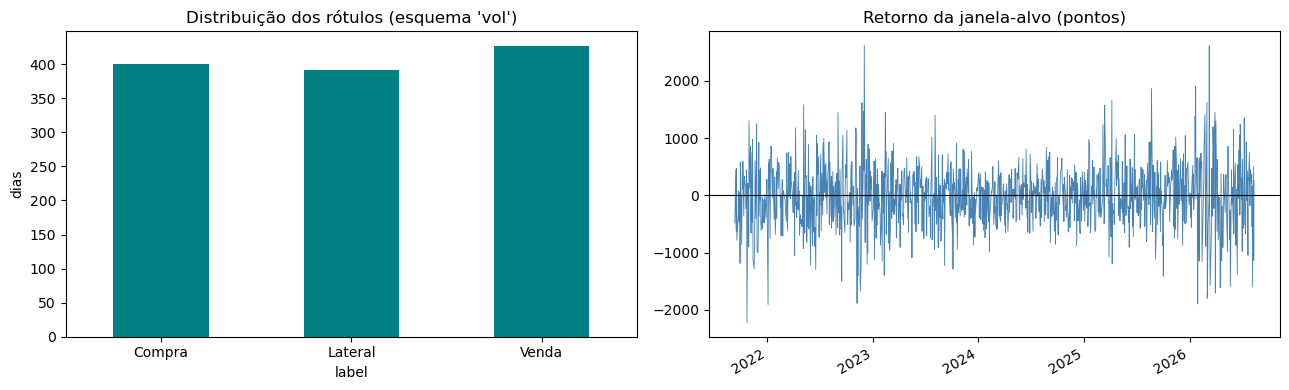

In [10]:
def construir_labels(df, janela, esquema):
    inicio, fim = janela
    jan = df.between_time(inicio, fim)
    agg = jan.resample("D").agg(
        ab=("Abertura", "first"), fe=("Fechamento", "last"),
        mx=("Maxima", "max"), mn=("Minima", "min"),
    ).dropna()

    retorno = agg["fe"] - agg["ab"]
    pavio = pd.Series(np.where(retorno >= 0, agg["ab"] - agg["mn"], agg["mx"] - agg["ab"]),
                      index=agg.index)

    if esquema == "fixo":
        cond = [(retorno > LIMIAR_RETORNO) & (pavio < LIMIAR_PAVIO),
                (retorno < -LIMIAR_RETORNO) & (pavio < LIMIAR_PAVIO)]
        y = pd.Series(np.select(cond, ["Compra", "Venda"], default="Lateral"), index=agg.index)

    elif esquema == "vol":
        # escala robusta: mediana móvel de |retorno| dos últimos 60 dias, só com passado
        escala = retorno.abs().rolling(60, min_periods=20).median().shift(1)
        k_ret = LIMIAR_RETORNO / escala.median()
        k_pav = LIMIAR_PAVIO / escala.median()
        cond = [(retorno > k_ret * escala) & (pavio < k_pav * escala),
                (retorno < -k_ret * escala) & (pavio < k_pav * escala)]
        y = pd.Series(np.select(cond, ["Compra", "Venda"], default="Lateral"), index=agg.index)
        y[escala.isna()] = np.nan

    elif esquema == "tercis":
        r = retorno / agg["ab"]
        q33 = r.rolling(250, min_periods=100).quantile(0.333).shift(1)
        q67 = r.rolling(250, min_periods=100).quantile(0.667).shift(1)
        y = pd.Series(np.select([r <= q33, r >= q67], ["Venda", "Compra"], default="Lateral"),
                      index=agg.index)
        y[q33.isna()] = np.nan
    else:
        raise ValueError(f"Esquema desconhecido: {esquema}")

    return y.rename("label"), retorno.rename("retorno_pts"), pavio.rename("pavio_pts")


y_todas, retorno_alvo, pavio_alvo = construir_labels(df, JANELA_ALVO, ESQUEMA_LABEL)

dados = X_todas.join(y_todas, how="inner").dropna()
X_all, y_all = dados.drop(columns="label"), dados["label"]

print(f"Amostras alinhadas : {len(X_all)}")
print(f"Features           : {X_all.shape[1]}")
print(f"Amostra por feature: {len(X_all) / X_all.shape[1]:.0f} : 1")
print(f"\nDistribuição das classes:")
print(y_all.value_counts().to_string())
print(f"\nMediana de |retorno| na janela-alvo: {retorno_alvo.abs().median():.0f} pontos")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
y_all.value_counts().reindex(CLASSES).plot.bar(ax=ax[0], color="teal", rot=0)
ax[0].set_title(f"Distribuição dos rótulos (esquema '{ESQUEMA_LABEL}')")
ax[0].set_ylabel("dias")
retorno_alvo.reindex(y_all.index).plot(ax=ax[1], lw=0.6, color="steelblue")
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_title("Retorno da janela-alvo (pontos)")
plt.tight_layout(); plt.show()

---
## 5. Protocolo de avaliação

É o coração do notebook. Se essa seção estiver errada, todo resultado depois dela é
ficção — e ficção convincente, porque erro de protocolo sempre deixa o número *melhor*.

### 5.1 O holdout sai agora, não depois

A primeira coisa que a célula faz é cortar os **últimos 20% dos dias** e guardar. Eles não
voltam até a seção 10.

A ordem importa: separar agora significa que nenhuma decisão que eu tomar no meio do
caminho — qual feature usar, qual rótulo, qual modelo, quais hiperparâmetros — pode ter
sido influenciada por esses dias. Se eu separasse depois de já ter olhado a base inteira,
o holdout seria só um pedaço de dado que eu já vi, com outro nome.

E o corte é **cronológico**, não aleatório. O holdout é o futuro em relação ao treino,
igual à situação real de operar.

### 5.2 Walk-forward, não validação cruzada normal

`TimeSeriesSplit` funciona assim, com 5 folds:

```
fold 1:  [treino......]  [teste]
fold 2:  [treino.............]  [teste]
fold 3:  [treino..................]  [teste]
fold 4:  [treino.......................]  [teste]
fold 5:  [treino............................]  [teste]
             tempo →
```

O treino sempre cresce para trás e o teste sempre fica à frente. Nunca o contrário.

Validação cruzada comum embaralha os dados e treina em dias posteriores para prever dias
anteriores. Em série temporal isso é vazamento puro: o modelo aprende regimes de mercado
que, na hora da previsão, ainda não teriam acontecido. O número que sai é ótimo e não
significa nada.

**O `StandardScaler` é ajustado dentro de cada fold**, só na parte de treino. Ajustar na
base toda vazaria a média e o desvio do futuro para dentro do treino — é um vazamento
sutil, que quase ninguém percebe, e que também melhora o resultado artificialmente.

### 5.3 Baseline em todo teste

Junto com cada modelo eu rodo um `DummyClassifier`. Uso dois tipos, porque eles medem
coisas diferentes:

- **`most_frequent`** — chuta sempre a classe mais comum. É o piso da **acurácia**. Com a
  minha distribuição ele acerta ~35%, o que já dá para confundir com "modelo funcionando".
- **`stratified`** — sorteia respeitando a proporção das classes. É o piso do
  **F1-macro**, que o baseline majoritário destrói (ele zera duas das três classes).

Um modelo só aprendeu alguma coisa se **superar os dois**, de forma consistente entre os
folds. Ganho médio positivo com metade dos folds negativos não conta.

### 5.4 Dez sementes, não uma

Rede neural com semente diferente dá resultado diferente. Modelos com amostragem
aleatória (`subsample`, `bootstrap`) também. Uma rodada só mede **a sorte daquela
inicialização**, não a qualidade do modelo.

Por isso tudo roda com no mínimo 10 sementes e o que eu reporto é **média ±
desvio-padrão**. Quando o desvio entre sementes é da mesma ordem que a diferença entre
dois modelos, esses dois modelos são indistinguíveis — e isso é uma informação, não um
detalhe.

### 5.5 As funções desta seção

| Função | O que faz |
|---|---|
| `walk_forward` | Um passe de 5 folds; devolve acurácia, F1 e o ganho sobre o baseline |
| `avaliar_multi_semente` | Roda o anterior com N sementes e agrega em média ± dp |
| `prever_out_of_fold` | Junta as previsões dos folds de teste — cada dia previsto por um modelo que nunca o viu. É o que alimenta o backtest |
| `teste_permutacao` | Embaralha o rótulo N vezes para construir a distribuição do acaso |

O `prever_out_of_fold` merece atenção. Ele é o que permite fazer um backtest honesto: cada
previsão vem de um modelo treinado exclusivamente em dias anteriores àquele. Backtest
feito com previsão in-sample dá 80% de acerto e uma curva de capital linda que não
significa absolutamente nada.


In [11]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# ---- separa o holdout ANTES de qualquer experimento ----
n_holdout = int(len(X_all) * FRAC_HOLDOUT)
corte = len(X_all) - n_holdout

X_trab, y_trab = X_all.iloc[:corte], y_all.iloc[:corte]
X_hold, y_hold = X_all.iloc[corte:], y_all.iloc[corte:]

print(f"Trabalho          : {len(X_trab):4d} dias  ({X_trab.index.min():%Y-%m-%d} a {X_trab.index.max():%Y-%m-%d})")
print(f"HOLDOUT (intocado): {len(X_hold):4d} dias  ({X_hold.index.min():%Y-%m-%d} a {X_hold.index.max():%Y-%m-%d})")


def walk_forward(construir_modelo, X, y, n_splits=N_SPLITS, semente=0, detalhe=False):
    """Walk-forward cronológico. Devolve métricas médias do modelo e do baseline."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    m_acc, m_f1, b_acc, b_f1 = [], [], [], []

    for k, (i_tr, i_te) in enumerate(tscv.split(X), 1):
        scaler = StandardScaler().fit(X.iloc[i_tr])
        X_tr, X_te = scaler.transform(X.iloc[i_tr]), scaler.transform(X.iloc[i_te])
        y_tr, y_te = y.iloc[i_tr], y.iloc[i_te]

        modelo = construir_modelo(semente).fit(X_tr, y_tr)
        p_m = modelo.predict(X_te)
        p_b = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr).predict(X_te)

        m_acc.append(accuracy_score(y_te, p_m)); b_acc.append(accuracy_score(y_te, p_b))
        m_f1.append(f1_score(y_te, p_m, average="macro", zero_division=0))
        b_f1.append(f1_score(y_te, p_b, average="macro", zero_division=0))

        if detalhe:
            print(f"    fold {k} (teste={len(i_te):4d}): base={b_acc[-1]:.3f} "
                  f"modelo={m_acc[-1]:.3f} delta={m_acc[-1]-b_acc[-1]:+.3f}")

    return {"acc": np.mean(m_acc), "f1": np.mean(m_f1),
            "base_acc": np.mean(b_acc), "base_f1": np.mean(b_f1),
            "ganho": np.mean(m_acc) - np.mean(b_acc),
            "acc_por_fold": m_acc}


def avaliar_multi_semente(nome, construir_modelo, X, y, sementes=SEMENTES):
    """Roda o walk-forward com várias sementes. Rodada única não é resultado."""
    linhas = [walk_forward(construir_modelo, X, y, semente=s) for s in sementes]
    acc = np.array([r["acc"] for r in linhas])
    f1 = np.array([r["f1"] for r in linhas])
    ganho = np.array([r["ganho"] for r in linhas])
    return {"modelo": nome, "n_sementes": len(sementes),
            "acc_media": acc.mean(), "acc_dp": acc.std(),
            "f1_media": f1.mean(), "f1_dp": f1.std(),
            "ganho_medio": ganho.mean(), "ganho_dp": ganho.std(),
            "base_acc": linhas[0]["base_acc"],
            "acc_por_fold": np.mean([r["acc_por_fold"] for r in linhas], axis=0)}


def prever_out_of_fold(construir_modelo, X, y, n_splits=N_SPLITS, semente=0):
    """
    Previsões honestas: cada dia é previsto por um modelo treinado só em dias anteriores.
    Devolve apenas os dias cobertos pelos folds de teste.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    partes = []
    for i_tr, i_te in tscv.split(X):
        scaler = StandardScaler().fit(X.iloc[i_tr])
        modelo = construir_modelo(semente).fit(scaler.transform(X.iloc[i_tr]), y.iloc[i_tr])
        partes.append(pd.Series(modelo.predict(scaler.transform(X.iloc[i_te])),
                                index=X.index[i_te]))
    return pd.concat(partes)


def teste_permutacao(construir_modelo, X, y, n_perm=N_PERMUTACOES, semente=0):
    """
    Hipótese nula: as features não têm relação nenhuma com o rótulo.
    Embaralha y e mede o ganho sob o nulo. Devolve o p-valor empírico.
    """
    obs = walk_forward(construir_modelo, X, y, semente=semente)["ganho"]
    rng = np.random.default_rng(semente)
    nulos = np.empty(n_perm)
    t0 = time.time()
    for i in range(n_perm):
        y_perm = pd.Series(rng.permutation(y.values), index=y.index)
        nulos[i] = walk_forward(construir_modelo, X, y_perm, semente=semente)["ganho"]
    return {"ganho_observado": obs, "nulo_media": nulos.mean(), "nulo_dp": nulos.std(),
            "z": (obs - nulos.mean()) / nulos.std(),
            "p_valor": (np.sum(nulos >= obs) + 1) / (n_perm + 1),
            "segundos": time.time() - t0, "nulos": nulos}

print("\nProtocolo carregado.")

Trabalho          :  976 dias  (2021-09-10 a 2025-08-15)
HOLDOUT (intocado):  244 dias  (2025-08-18 a 2026-08-12)

Protocolo carregado.


---
## 6. Modelos tabulares

Sete modelos sobre as 15 features agregadas. Com 976 dias de trabalho, esse é o regime de
dados certo — as redes vêm na seção seguinte, mas já com a expectativa declarada de que
estão fora da zona de conforto delas.

### Quem está na lista e por quê

| Modelo | O que ele traz | Por que está aqui |
|---|---|---|
| **Baseline (majoritária)** | chuta sempre a classe mais comum | piso da acurácia — o número a bater |
| **Baseline (estratificado)** | sorteia na proporção das classes | piso do F1-macro |
| **Regressão logística** | fronteira linear | se um modelo linear já resolve, não preciso de nada mais complexo |
| **SVM (RBF)** | fronteira não linear via kernel | captura interação sem precisar de muitos dados |
| **Random Forest** | árvores independentes, votação | robusto a ruído e a feature irrelevante |
| **Gradient Boosting** | árvores em sequência, cada uma corrige a anterior | costuma ser o melhor em dado tabular deste tamanho |
| **XGBoost** | boosting com regularização mais forte | mesma família, implementação mais controlada |

A ordem não é acidental: ela vai do mais simples ao mais complexo. Se a regressão
logística já batesse o baseline, eu não precisaria de árvore nenhuma. E se nenhum deles
bate, é sinal de que o problema não está na capacidade do modelo.

### Os hiperparâmetros são propositalmente conservadores

`max_depth=2` no Gradient Boosting, `max_depth=4` e `min_samples_leaf=10` na Random
Forest, `learning_rate=0.05`. Nada disso foi otimizado.

Isso é deliberado. Com 976 amostras, uma busca de hiperparâmetros com dezenas de tentativas
encontraria a combinação que melhor se ajusta ao **ruído** do conjunto de validação, não a
que generaliza. Modelo raso e regularizado é a escolha certa nesse tamanho de amostra.

Se algum modelo mostrasse sinal aqui, aí sim valeria abrir uma busca — mas com validação
aninhada, com a busca acontecendo *dentro* de cada fold de treino.

### O wrapper do XGBoost

O XGBoost só aceita rótulo numérico. Em vez de espalhar conversão de classe pelo notebook
inteiro, embrulhei ele numa classe que converte texto→número na entrada e número→texto na
saída. Assim ele se comporta exatamente como os outros modelos do scikit-learn e o resto
do código não precisa saber da diferença.

### Como ler a tabela de resultados

A coluna que importa é **`ganho_medio`** — a diferença de acurácia entre o modelo e o
baseline majoritário. Positivo e consistente significa que aprendeu alguma coisa. Zero ou
negativo significa que não.

E olhe sempre o `acc_dp` junto: se o desvio entre sementes for maior que o ganho, o ganho
não é real.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

MODELOS_TABULARES = {
    "Baseline (majoritária)":   lambda s: DummyClassifier(strategy="most_frequent"),
    "Baseline (estratificado)": lambda s: DummyClassifier(strategy="stratified", random_state=s),
    "Regressão logística":      lambda s: LogisticRegression(max_iter=2000, C=1.0, random_state=s),
    "SVM (RBF)":                lambda s: SVC(C=1.0, gamma="scale", random_state=s),
    "Random Forest":            lambda s: RandomForestClassifier(
        n_estimators=300, max_depth=4, min_samples_leaf=10, random_state=s, n_jobs=-1),
    "Gradient Boosting":        lambda s: GradientBoostingClassifier(
        n_estimators=200, max_depth=2, learning_rate=0.05, subsample=0.8, random_state=s),
}

try:
    import xgboost as xgb

    class XGBTexto:
        """Wrapper para o XGBoost aceitar rótulo em texto igual aos outros modelos."""
        def __init__(self, semente):
            self.m = xgb.XGBClassifier(
                n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8,
                colsample_bytree=0.8, reg_lambda=1.0, random_state=semente, n_jobs=-1,
                objective="multi:softprob", num_class=3, verbosity=0)
            self.classes_ = np.array(CLASSES)

        def fit(self, X, y):
            self.m.fit(X, pd.Series(y).map({c: i for i, c in enumerate(CLASSES)}).values)
            return self

        def predict(self, X):
            return self.classes_[self.m.predict(X)]

    MODELOS_TABULARES["XGBoost"] = lambda s: XGBTexto(s)
except ImportError:
    print("xgboost indisponível — pulando esse modelo.\n")

resultados = []
for nome, ctor in MODELOS_TABULARES.items():
    t0 = time.time()
    r = avaliar_multi_semente(nome, ctor, X_trab, y_trab)
    r["segundos"] = time.time() - t0
    r["familia"] = "tabular"
    resultados.append(r)
    print(f"{nome:<26} acc={r['acc_media']:.3f}±{r['acc_dp']:.3f}  "
          f"f1m={r['f1_media']:.3f}±{r['f1_dp']:.3f}  "
          f"ganho={r['ganho_medio']:+.3f}  ({r['segundos']:.0f}s)")

tabela = pd.DataFrame(resultados).set_index("modelo")
tabela[["acc_media", "acc_dp", "f1_media", "f1_dp", "ganho_medio", "ganho_dp"]].round(4)

In [ ]:
ordem = tabela.sort_values("acc_media")
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(ordem.index, ordem["acc_media"], xerr=ordem["acc_dp"],
        color="teal", alpha=0.8, capsize=4)
ax.axvline(tabela["base_acc"].iloc[0], color="crimson", ls="--", lw=2,
           label=f"baseline = {tabela['base_acc'].iloc[0]:.3f}")
ax.axvline(1/3, color="gray", ls=":", lw=1.5, label="acaso (3 classes) = 0.333")
ax.set_xlabel("acurácia média no walk-forward (±1 dp entre sementes)")
ax.set_title("Modelos tabulares — walk-forward, 10 sementes")
ax.legend(); plt.tight_layout(); plt.show()

---
## 7. Modelos sequenciais (deep learning)

Aqui as arquiteturas recebem a **sequência inteira**, não o resumo. É a parte que responde
diretamente à discussão do começo do notebook sobre como conectar as velas na rede.

### O formato dos dados muda

Enquanto os modelos tabulares recebem uma matriz `(dias, 15)`, estes recebem um tensor 3D:

```
(1.220 dias, 24 velas, 5 medidas por vela)
```

As 5 medidas de cada vela são todas relativas ao preço, para funcionarem igual em qualquer
nível do índice:

| Medida | Fórmula | O que descreve |
|---|---|---|
| `r_retorno` | `(fecha − abre) / abre` | direção e tamanho do corpo |
| `r_range` | `(máxima − mínima) / abre` | amplitude total da vela |
| `r_pav_sup` | `(máxima − topo do corpo) / abre` | rejeição de preço em cima |
| `r_pav_inf` | `(base do corpo − mínima) / abre` | rejeição de preço embaixo |
| `r_vol` | volume ÷ média móvel de 50 velas | volume relativo ao normal recente |

Juntas, elas descrevem a **forma** de cada vela — que é exatamente o que a análise técnica
clássica lê num gráfico de candles.

### As quatro arquiteturas e o viés de cada uma

**MLP** — é a Arquitetura 2 da introdução. Achata a sequência e conecta tudo a todos os
neurônios. Cada neurônio oculto vê todas as 24 velas ao mesmo tempo e pode virar um
detector de padrão que combina velas distantes.
*Limitação:* não tem noção de ordem. Para ele, trocar a vela 3 com a vela 20 seria só
outra entrada qualquer.

**CNN 1D** — resolve justamente a rigidez do Teste 1. O filtro convolucional desliza pela
sequência procurando o mesmo padrão **em qualquer posição**. Se um engolfo de alta é sinal
de compra, a CNN reconhece ele às 09:30 e às 10:30 com os mesmos pesos.
Uso `padding="causal"` para que cada posição só enxergue o passado, nunca o futuro.

**LSTM** — processa vela a vela carregando um estado interno. Em vez de olhar tudo de uma
vez, ela constrói uma memória do que veio antes e decide o que guardar e o que esquecer.
É a arquitetura desenhada para série temporal.
*Limitação:* é a que mais precisa de dados, e 970 amostras é pouco.

**TCN** — convolução dilatada. Empilha camadas com espaçamento crescente (1, 2, 4) e
alcança a janela inteira com poucas camadas. Combina o campo receptivo grande da LSTM com
o treino paralelo da CNN.

### A expectativa que eu registro antes de rodar

Com ~970 amostras de treino, **essas quatro famílias estão fora do regime de dados
delas**. Deep learning brilha com dezenas de milhares de exemplos; aqui há três ordens de
grandeza a menos.

Eu não espero que superem o Gradient Boosting. Estou escrevendo isso *antes* de ver o
resultado justamente para não inventar explicação depois. Se não superarem, isso faz parte
do achado e vai ser reportado.

### Detalhes de treino

- **`EarlyStopping`** monitorando `val_loss` com paciência de 20 épocas e
  `restore_best_weights=True`. Sem isso, 200 épocas em 970 amostras é decorar garantido.
- **`validation_split=0.2` com `shuffle=False`** — a validação são os últimos 20% do fold
  de treino, cronologicamente. Embaralhar aqui seria vazamento.
- **Normalização por fold**, com média e desvio calculados só no treino daquele fold.
- **`clear_session()`** entre folds, senão o TensorFlow acumula grafos e a memória cresce
  sem parar.

`N_SEMENTES_DL` começa em 3 porque essa é a célula mais demorada do notebook. Para a
rodada que for virar resultado publicável, sobe para 10.


In [ ]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import (Input, Dense, Dropout, Conv1D, LSTM,
                                         BatchNormalization, GlobalAveragePooling1D, Flatten)
    from tensorflow.keras.callbacks import EarlyStopping
    os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
    tf.get_logger().setLevel("ERROR")
    TF_OK = True
    print(f"TensorFlow {tf.__version__} disponível.")
except ImportError:
    TF_OK = False
    print("TensorFlow NÃO instalado — a seção 7 inteira será pulada.")


def construir_tensor(df, janela, indice_dias):
    """Tensor 3D (dias, velas, features_por_vela) para as arquiteturas sequenciais."""
    inicio, fim = janela
    jan = df.between_time(inicio, fim).copy()

    jan["r_retorno"] = (jan["Fechamento"] - jan["Abertura"]) / jan["Abertura"]
    jan["r_range"]   = (jan["Maxima"] - jan["Minima"]) / jan["Abertura"]
    jan["r_pav_sup"] = (jan["Maxima"] - jan[["Abertura", "Fechamento"]].max(axis=1)) / jan["Abertura"]
    jan["r_pav_inf"] = (jan[["Abertura", "Fechamento"]].min(axis=1) - jan["Minima"]) / jan["Abertura"]
    jan["r_vol"]     = jan["Volume_Real"] / jan["Volume_Real"].rolling(50, min_periods=1).mean()
    cols = ["r_retorno", "r_range", "r_pav_sup", "r_pav_inf", "r_vol"]

    grupos = {d: g for d, g in jan.groupby(jan.index.normalize())}
    n_velas = int(np.median([len(g) for g in grupos.values()]))

    tensor, dias_ok = [], []
    for d in indice_dias:
        g = grupos.get(d)
        if g is None or len(g) < n_velas:
            continue
        tensor.append(g[cols].iloc[:n_velas].values)
        dias_ok.append(d)
    return np.array(tensor), pd.DatetimeIndex(dias_ok), cols


if TF_OK:
    T_all, dias_T, cols_T = construir_tensor(df, JANELA_FEATURES, X_all.index)
    # bloco de contexto alinhado ao tensor — vira a SEGUNDA entrada das redes
    C_all = X_all.loc[dias_T, COLUNAS_CONTEXTO].values.astype("float32")

    print(f"Entrada sequencial: {T_all.shape}  (dias, velas, features_por_vela)")
    print(f"  features por vela: {cols_T}")
    print(f"Entrada de contexto: {C_all.shape}  (dias, features de contexto)")
    print(f"  features: {COLUNAS_CONTEXTO}")
    print(f"\nValores sequenciais por amostra: {T_all.shape[1] * T_all.shape[2]}  "
          f"→ razão {len(T_all)/(T_all.shape[1]*T_all.shape[2]):.1f} : 1")

In [ ]:
ARQUITETURAS = {}

if globals().get("TF_OK", False):
    from tensorflow.keras.layers import concatenate

    def _compilar(m, lr=1e-3):
        m.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss="categorical_crossentropy", metrics=["accuracy"])
        return m

    def _cabeca(x_seq, e_ctx):
        """Junta o ramo sequencial ao ramo de contexto e fecha com a camada de decisão."""
        c = Dense(16, activation="relu")(e_ctx)
        x = concatenate([x_seq, c])
        x = Dense(32, activation="relu")(x)
        x = Dropout(0.3)(x)
        return Dense(3, activation="softmax")(x)

    def mlp(shape_seq, shape_ctx, semente):
        """Arquitetura 2 da introdução: densa, cada neurônio vê todas as velas."""
        tf.keras.utils.set_random_seed(semente)
        e_seq, e_ctx = Input(shape=shape_seq), Input(shape=shape_ctx)
        x = Flatten()(e_seq)
        x = Dense(64, activation="relu")(x); x = Dropout(0.5)(x)
        x = Dense(32, activation="relu")(x); x = Dropout(0.3)(x)
        return _compilar(Model([e_seq, e_ctx], _cabeca(x, e_ctx)))

    def cnn1d(shape_seq, shape_ctx, semente):
        """Detecta o mesmo padrão em qualquer posição da sequência."""
        tf.keras.utils.set_random_seed(semente)
        e_seq, e_ctx = Input(shape=shape_seq), Input(shape=shape_ctx)
        x = Conv1D(32, 3, activation="relu", padding="causal")(e_seq)
        x = BatchNormalization()(x); x = Dropout(0.3)(x)
        x = Conv1D(32, 3, activation="relu", padding="causal")(x)
        x = GlobalAveragePooling1D()(x)
        return _compilar(Model([e_seq, e_ctx], _cabeca(x, e_ctx)))

    def lstm(shape_seq, shape_ctx, semente):
        """Carrega estado ao longo da sequência de velas."""
        tf.keras.utils.set_random_seed(semente)
        e_seq, e_ctx = Input(shape=shape_seq), Input(shape=shape_ctx)
        x = LSTM(32)(e_seq); x = BatchNormalization()(x); x = Dropout(0.3)(x)
        return _compilar(Model([e_seq, e_ctx], _cabeca(x, e_ctx)))

    ARQUITETURAS = {"MLP": mlp, "CNN 1D": cnn1d, "LSTM": lstm}

    try:
        from tcn import TCN
        def tcn_model(shape_seq, shape_ctx, semente):
            tf.keras.utils.set_random_seed(semente)
            e_seq, e_ctx = Input(shape=shape_seq), Input(shape=shape_ctx)
            x = TCN(nb_filters=32, kernel_size=3, dilations=[1, 2, 4],
                    padding="causal", return_sequences=False, dropout_rate=0.2)(e_seq)
            return _compilar(Model([e_seq, e_ctx], _cabeca(x, e_ctx)))
        ARQUITETURAS["TCN"] = tcn_model
    except ImportError:
        print("keras-tcn indisponível — TCN fora da lista.")

    print(f"Arquiteturas definidas (2 entradas: sequencial + contexto): {list(ARQUITETURAS)}")
else:
    print("TensorFlow indisponível — nenhuma arquitetura definida.")


def walk_forward_keras(construir, T, C, y_oh, y_lab, n_splits=N_SPLITS, semente=0):
    """
    Walk-forward para Keras com duas entradas.
    Os dois blocos são padronizados separadamente, e sempre só com o treino do fold.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    m_acc, m_f1, b_acc = [], [], []
    for i_tr, i_te in tscv.split(T):
        # bloco sequencial
        mu = T[i_tr].reshape(-1, T.shape[-1]).mean(0)
        sd = T[i_tr].reshape(-1, T.shape[-1]).std(0) + 1e-9
        T_tr, T_te = (T[i_tr] - mu) / sd, (T[i_te] - mu) / sd
        # bloco de contexto
        mu_c, sd_c = C[i_tr].mean(0), C[i_tr].std(0) + 1e-9
        C_tr, C_te = (C[i_tr] - mu_c) / sd_c, (C[i_te] - mu_c) / sd_c

        modelo = construir(T.shape[1:], C.shape[1:], semente)
        modelo.fit([T_tr, C_tr], y_oh[i_tr], epochs=200, batch_size=32, verbose=0,
                   validation_split=0.2, shuffle=False,
                   callbacks=[EarlyStopping(monitor="val_loss", patience=20,
                                            restore_best_weights=True)])
        p = np.array(CLASSES)[np.argmax(modelo.predict([T_te, C_te], verbose=0), axis=1)]
        v = y_lab.iloc[i_te].values
        m_acc.append(accuracy_score(v, p))
        m_f1.append(f1_score(v, p, average="macro", zero_division=0))
        b_acc.append(accuracy_score(v, DummyClassifier(strategy="most_frequent")
                                    .fit(T_tr.reshape(len(i_tr), -1), y_lab.iloc[i_tr])
                                    .predict(T_te.reshape(len(i_te), -1))))
        tf.keras.backend.clear_session()
    return np.mean(m_acc), np.mean(m_f1), np.mean(b_acc)

In [ ]:
# Esta é a célula mais demorada do notebook. Comece com poucas sementes.
N_SEMENTES_DL = 3   # subir para 10 na rodada final que for para o paper

if not TF_OK:
    print("Pulado: TensorFlow indisponível.")
elif not ARQUITETURAS:
    print("Pulado: nenhuma arquitetura definida.")
else:
    comum = X_trab.index.intersection(dias_T)
    pos = {d: i for i, d in enumerate(dias_T)}
    idx = [pos[d] for d in comum]
    T_trab, C_trab = T_all[idx], C_all[idx]
    y_dl = y_trab.loc[comum]
    y_oh = pd.get_dummies(y_dl).reindex(columns=CLASSES, fill_value=0).values.astype("float32")
    print(f"Deep learning sobre {len(T_trab)} amostras")
    print(f"  entrada sequencial: {T_trab.shape}")
    print(f"  entrada de contexto: {C_trab.shape}\n")

    for nome, ctor_dl in ARQUITETURAS.items():
        t0 = time.time()
        accs, f1s, bases = [], [], []
        for s in range(N_SEMENTES_DL):
            a, f, b = walk_forward_keras(ctor_dl, T_trab, C_trab, y_oh, y_dl, semente=s)
            accs.append(a); f1s.append(f); bases.append(b)
        r = {"modelo": nome, "n_sementes": N_SEMENTES_DL, "familia": "sequencial",
             "acc_media": np.mean(accs), "acc_dp": np.std(accs),
             "f1_media": np.mean(f1s), "f1_dp": np.std(f1s),
             "ganho_medio": np.mean(accs) - np.mean(bases), "ganho_dp": np.std(accs),
             "base_acc": np.mean(bases), "acc_por_fold": [np.nan] * N_SPLITS,
             "segundos": time.time() - t0}
        resultados.append(r)
        print(f"{nome:<26} acc={r['acc_media']:.3f}±{r['acc_dp']:.3f}  "
              f"f1m={r['f1_media']:.3f}±{r['f1_dp']:.3f}  "
              f"ganho={r['ganho_medio']:+.3f}  ({r['segundos']:.0f}s)")

    tabela = pd.DataFrame(resultados).set_index("modelo")

tabela[["familia", "n_sementes", "acc_media", "acc_dp", "f1_media", "ganho_medio"]].round(4)

---
## 8. Comparação estatística

Duas perguntas diferentes, que muita gente confunde:

1. **"Algum modelo aprendeu alguma coisa?"** → teste de permutação
2. **"Algum modelo é melhor que os outros?"** → Friedman + Nemenyi

Se a primeira falhar, a segunda perde a graça — estarei comparando ruído com ruído.

### 8.1 Teste de permutação

A pergunta que ele responde: *o ganho que eu observei poderia ter aparecido por acaso?*

Como funciona:

1. Embaralho os rótulos aleatoriamente, destruindo qualquer relação entre features e
   resposta, mas mantendo a distribuição das classes intacta
2. Rodo o walk-forward inteiro com esses rótulos embaralhados e anoto o ganho
3. Repito 200 vezes → isso constrói a **distribuição do acaso** para este problema
   específico, com este tamanho de amostra e este modelo
4. Vejo onde o ganho real cai nessa distribuição

O **p-valor** é a fração de embaralhamentos que deram ganho igual ou maior que o real. Se
p = 0,33, significa que **um terço dos embaralhamentos aleatórios foi tão bom quanto o meu
modelo**. Não dá para chamar isso de sinal.

O **z** diz a mesma coisa em desvios-padrão: quantos desvios o resultado real está acima
da média do acaso. Abaixo de 2 é ruído.

A grande vantagem desse teste sobre uma fórmula fechada é que ele não assume nada sobre a
distribuição dos dados. Ele mede o acaso **neste** problema, com **este** número de
amostras e **este** esquema de validação.

> A permutação roda no melhor modelo **tabular**, e não no melhor geral. Motivo prático:
> são 200 reconstruções do modelo, e uma rede levaria horas. Quando o melhor geral é uma
> rede, a célula avisa isso explicitamente em vez de esconder a substituição.

### 8.2 Friedman + Nemenyi

O procedimento padrão para comparar vários classificadores (Demšar, 2006, *JMLR*), e o que
um revisor vai esperar ver.

**Friedman** trabalha com **ranks**, não com acurácia bruta. Em cada fold eu ordeno os
modelos do melhor para o pior; o teste pergunta se a distribuição desses ranks é diferente
do que se esperaria por sorteio. Usar rank em vez do valor absoluto evita que um fold
atípico domine a comparação.

**Nemenyi** vem depois, se o Friedman apontar diferença. Ele calcula a **distância
crítica**:

```
CD = q(α) · √( k(k+1) / 6n )        k = nº de modelos, n = nº de folds
```

Dois modelos só são estatisticamente diferentes se os ranks médios deles estiverem
separados por mais que `CD`. Com 7 modelos e 5 folds, `CD ≈ 4,0` numa escala de ranks que
vai de 1 a 7 — ou seja, o teste tem **pouquíssimo poder**. Com 5 folds só, é preciso uma
diferença enorme para detectar qualquer coisa.

> **Como ler o Friedman sem se enganar.** Um p < 0,05 diz que *existe* diferença entre os
> modelos — **não** que algum deles é bom. Se o baseline aparecer no topo do ranking, o que
> o teste detectou foi que os modelos reais são significativamente **piores** do que não
> fazer nada. A célula abaixo checa isso e avisa. Sempre confiro a posição do baseline
> antes de interpretar qualquer coisa.


In [ ]:
# escolhe o melhor de cada categoria, ignorando os baselines
reais = tabela.drop(index=[i for i in tabela.index if "Baseline" in i], errors="ignore")
melhor_geral = reais["ganho_medio"].idxmax()

tab_reais = reais[reais.index.isin(MODELOS_TABULARES)]
melhor_tabular = tab_reais["ganho_medio"].idxmax()
ctor = MODELOS_TABULARES[melhor_tabular]

print(f"Melhor modelo no geral  : {melhor_geral} (ganho {reais.loc[melhor_geral, 'ganho_medio']:+.4f})")
print(f"Melhor modelo tabular   : {melhor_tabular} (ganho {reais.loc[melhor_tabular, 'ganho_medio']:+.4f})")
if melhor_geral != melhor_tabular:
    print(f"\nO melhor geral é uma rede. A permutação, o backtest e o holdout usam")
    print(f"'{melhor_tabular}', que é reconstruível de forma barata e repetida.")

perm = teste_permutacao(ctor, X_trab, y_trab)
print(f"\n--- Teste de permutação: {melhor_tabular} ---")
print(f"Permutações ..... {N_PERMUTACOES} em {perm['segundos']:.0f}s")
print(f"Ganho observado . {perm['ganho_observado']:+.4f}")
print(f"Nulo ............ {perm['nulo_media']:+.4f} ± {perm['nulo_dp']:.4f}")
print(f"z ............... {perm['z']:.2f}")
print(f"p-valor ......... {perm['p_valor']:.4f}")
print(">>> " + ("SIGNIFICATIVO a 5%" if perm["p_valor"] < 0.05 else "NÃO significativo a 5%"))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(perm["nulos"], bins=40, color="lightsteelblue", edgecolor="white")
ax.axvline(perm["ganho_observado"], color="crimson", lw=2.5,
           label=f"observado = {perm['ganho_observado']:+.4f}")
ax.axvline(np.percentile(perm["nulos"], 95), color="k", ls="--", lw=1.5, label="p95 do nulo")
ax.set_xlabel("ganho sobre o baseline"); ax.set_ylabel("frequência")
ax.set_title(f"Distribuição nula por permutação — {melhor_tabular}")
ax.legend(); plt.tight_layout(); plt.show()

In [ ]:
from scipy.stats import friedmanchisquare, rankdata

comparaveis = tabela[tabela["acc_por_fold"].apply(
    lambda v: isinstance(v, (list, np.ndarray)) and not np.any(pd.isna(v)))]

if len(comparaveis) < 3:
    print(f"Só {len(comparaveis)} modelos comparáveis por fold — Friedman precisa de pelo menos 3.")
else:
    M = np.vstack(comparaveis["acc_por_fold"].values)      # (modelos, folds)
    stat, p = friedmanchisquare(*M)
    print(f"Friedman: chi2 = {stat:.3f}, p = {p:.4f}  ({len(comparaveis)} modelos, {M.shape[1]} folds)")
    print(">>> " + ("Existe diferença entre os modelos." if p < 0.05
                    else "NÃO existe diferença detectável entre os modelos."))

    ranks = np.array([rankdata(-M[:, j]) for j in range(M.shape[1])]).mean(axis=0)
    rk = pd.Series(ranks, index=comparaveis.index).sort_values()
    print("\nRank médio (menor = melhor):")
    print(rk.round(2).to_string())

    pos_base = [i for i, nome in enumerate(rk.index) if "Baseline" in nome]
    if pos_base and min(pos_base) == 0:
        print("\n>>> ATENÇÃO: o baseline está em primeiro. Nenhum modelo bateu o trivial.")

    k, n = len(rk), M.shape[1]
    q_alpha = {2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728, 6: 2.850,
               7: 2.949, 8: 3.031, 9: 3.102, 10: 3.164}.get(k, 3.2)
    cd = q_alpha * np.sqrt(k * (k + 1) / (6 * n))
    print(f"\nDistância crítica (Nemenyi, alpha=0,05, k={k}, n={n}): {cd:.2f}")
    print(f"Amplitude observada dos ranks: {rk.max() - rk.min():.2f}")
    print(">>> " + ("Existem pares significativamente diferentes."
                    if (rk.max() - rk.min()) > cd else "NENHUM par difere significativamente."))

---
## 9. Avaliação econômica

Acurácia não paga conta. Essa seção traduz previsão em dinheiro, que é a única métrica que
importa no fim.

### As regras da simulação

| Previsão | Ação |
|---|---|
| **Compra** | compro na abertura das 11:00, saio no fechamento das 11:59 |
| **Venda** | vendo na abertura das 11:00, saio no fechamento das 11:59 |
| **Lateral** | fico de fora — não opero e não pago nada |

Cada operação paga **3 pontos** de custo (`CUSTO_PONTOS`), cobrindo spread e corretagem
de ida e volta. Cada ponto vale **R$ 0,20** (`VALOR_PONTO`), que é o valor do mini-índice.

O custo é o que separa um backtest sério de um exercício de fantasia. Com 500 operações,
3 pontos cada, são 1.500 pontos consumidos só de atrito — e é comum uma estratégia que
parecia lucrativa virar prejuízo exatamente aí.

### As métricas e o que cada uma revela

| Métrica | O que responde |
|---|---|
| `operações` | Quantos dias o modelo decidiu operar. Se for perto de zero, ele virou um "fica de fora" caro |
| `taxa_acerto` | % de operações que fecharam positivas **depois do custo** |
| `pontos_liquidos` | O resultado acumulado, já com custo |
| `resultado_R$` | O mesmo, em dinheiro |
| `expectativa_pts_op` | Quanto se ganha (ou perde) por operação, em média. **É a métrica mais honesta** |
| `drawdown_max_pts` | A maior sequência de perda acumulada. É o que determina se dá para aguentar operar |

Taxa de acerto alta com expectativa negativa é um padrão clássico: acerta muito, ganha
pouco em cada acerto, e perde muito nos poucos erros.

### Os dois pontos de comparação

**Aleatório** — sorteia entre as três classes. Mostra o que sai de uma estratégia sem
nenhuma informação.

**Só comprar** — compra todo dia, sem pensar. É o equivalente ao buy-and-hold da janela, e
é o benchmark mais duro: se o modelo não bate "comprar sempre", ele não está agregando
nada.

> **As previsões aqui são out-of-fold.** Cada dia é previsto por um modelo que nunca o
> viu, coletado ao longo dos folds do walk-forward. Isso não é detalhe: backtest com
> previsão in-sample dá 80% de acerto e uma curva de capital linda que **não significa
> nada**. É o erro mais comum e mais caro dessa área — e eu já cometi ele neste projeto.
>
> **A coluna "aleatório" é um sorteio só.** Se ela aparecer ganhando, não quer dizer que o
> acaso é melhor que o modelo — quer dizer que a variância entre sorteios é maior que a
> diferença entre as estratégias, o que por si só já é um resultado. Para comparar de
> verdade, seriam 1.000 sorteios e uma comparação de distribuições.


In [ ]:
def backtest(y_verdadeiro, y_previsto, retorno_pts, custo=CUSTO_PONTOS, valor=VALOR_PONTO):
    """P&L em pontos e em reais. 'Lateral' significa não operar."""
    r = retorno_pts.reindex(y_verdadeiro.index)
    direcao = pd.Series(0.0, index=y_verdadeiro.index)
    direcao[y_previsto == "Compra"] = 1.0
    direcao[y_previsto == "Venda"] = -1.0

    operou = direcao != 0
    liquido = direcao * r - operou * custo
    vencedoras = liquido[operou & (liquido > 0)]
    perdedoras = liquido[operou & (liquido <= 0)]

    return {
        "operações": int(operou.sum()),
        "taxa_acerto": float((liquido[operou] > 0).mean()) if operou.sum() else np.nan,
        "pontos_liquidos": float(liquido.sum()),
        "resultado_R$": float(liquido.sum() * valor),
        "expectativa_pts_op": float(liquido[operou].mean()) if operou.sum() else np.nan,
        "ganho_medio": float(vencedoras.mean()) if len(vencedoras) else np.nan,
        "perda_media": float(perdedoras.mean()) if len(perdedoras) else np.nan,
        "drawdown_max_pts": float((liquido.cumsum().cummax() - liquido.cumsum()).max()),
        "curva": liquido.cumsum(),
    }


prev_oof = prever_out_of_fold(ctor, X_trab, y_trab)
y_oof = y_trab.loc[prev_oof.index]

bt = backtest(y_oof, prev_oof, retorno_alvo)
aleatorio = backtest(y_oof, pd.Series(
    np.random.default_rng(0).choice(CLASSES, len(y_oof)), index=y_oof.index), retorno_alvo)
so_comprar = backtest(y_oof, pd.Series("Compra", index=y_oof.index), retorno_alvo)

print(f"Modelo: {melhor_tabular} | previsões out-of-fold: {len(prev_oof)} dias\n")
print(f"{'':<22}{'modelo':>14}{'aleatório':>14}{'só comprar':>14}")
for ch in ["operações", "taxa_acerto", "pontos_liquidos", "resultado_R$",
           "expectativa_pts_op", "drawdown_max_pts"]:
    print(f"{ch:<22}{bt[ch]:>14,.2f}{aleatorio[ch]:>14,.2f}{so_comprar[ch]:>14,.2f}")

fig, ax = plt.subplots(figsize=(11, 4))
bt["curva"].plot(ax=ax, color="teal", lw=1.8, label=f"{melhor_tabular} (out-of-fold)")
aleatorio["curva"].plot(ax=ax, color="gray", ls="--", label="aleatório")
so_comprar["curva"].plot(ax=ax, color="orange", ls=":", label="só comprar")
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("pontos acumulados (líquidos)")
ax.set_title("Resultado no walk-forward out-of-fold, já com custos")
ax.legend(); plt.tight_layout(); plt.show()

if bt["pontos_liquidos"] <= 0:
    print("\n>>> Resultado líquido NEGATIVO. Depois do custo, a estratégia perde dinheiro.")

---
## 10. Holdout final

Os **244 dias** separados lá na seção 5, que nenhuma decisão deste notebook encostou.

### Por que ele existe

Todo o resto do notebook usou o conjunto de trabalho repetidas vezes: escolhi features
olhando para ele, escolhi rótulo olhando para ele, comparei sete modelos nele. Cada uma
dessas decisões consumiu um pouco da independência daquele dado.

Isso não é erro — é como se desenvolve modelo. Mas significa que o resultado do
walk-forward é **otimista**, porque as escolhas foram feitas sabendo dele. O holdout é a
única medida que não tem esse viés.

### A regra de uma olhada só

**Rode esta seção uma vez, no fim de tudo.**

Se eu abrir, não gostar do resultado, ajustar alguma coisa e abrir de novo, o holdout
deixou de existir. Ele vira mais um conjunto de validação, com a diferença de que agora eu
acho que ele é confiável — o que é pior do que não ter holdout nenhum.

A flag `EXECUTAR_HOLDOUT` fica em `False` de propósito, para eu não abrir por distração.

### O que testar aqui

A configuração combinada na introdução: **`09:00–11:59 → 12:00–12:59`**.

Vale repetir por que essa e não outra. No teste de janelas ela teve o maior ganho (+0,051),
mas **não é por isso** que ela foi escolhida — o maior de sete sorteios de ruído cairia
mais ou menos nesse valor de qualquer jeito. Ela foi escolhida porque tem uma
**justificativa causal independente do resultado**: a janela de entrada inclui as 11:30, a
abertura americana. Se o mecanismo que eu descrevi no começo do notebook for real, é ali
que ele deveria aparecer.

Um resultado positivo nessa configuração eu consigo explicar. Nas outras, seria sorte com
uma história inventada por cima.

Para testar: mude `JANELA_FEATURES` e `JANELA_ALVO` na seção 1 e rode o notebook do começo.

### Como interpretar o que sair

| Situação | Leitura |
|---|---|
| Ganho positivo e P&L positivo | Há sinal. Próximo passo é robustez: outros períodos, outros custos |
| Ganho positivo, P&L negativo | Acerta mais que o acaso, mas não o suficiente para pagar o atrito |
| Ganho ≈ 0 | Confirma o resultado nulo. É uma conclusão, não uma falha |
| Ganho negativo | O modelo é pior que não fazer nada nessa janela |

Nos três últimos casos o caminho é o mesmo: seguir para a bateria de variantes, sem tentar
salvar esta configuração com ajuste fino.


In [ ]:
EXECUTAR_HOLDOUT = False   # mude para True só quando todo o resto estiver fechado

if not EXECUTAR_HOLDOUT:
    print("Holdout NÃO executado (EXECUTAR_HOLDOUT = False).")
    print(f"Reservados {len(X_hold)} dias: {X_hold.index.min():%Y-%m-%d} a {X_hold.index.max():%Y-%m-%d}")
    print("Mude a flag para True quando tudo o mais estiver decidido — e só uma vez.")
else:
    scaler = StandardScaler().fit(X_trab)
    modelo_final = ctor(0).fit(scaler.transform(X_trab), y_trab)
    prev_hold = pd.Series(modelo_final.predict(scaler.transform(X_hold)), index=X_hold.index)
    base_hold = pd.Series(
        DummyClassifier(strategy="most_frequent").fit(scaler.transform(X_trab), y_trab)
        .predict(scaler.transform(X_hold)), index=X_hold.index)

    acc_m, acc_b = accuracy_score(y_hold, prev_hold), accuracy_score(y_hold, base_hold)
    print(f"=== HOLDOUT — {len(X_hold)} dias, {X_hold.index.min():%Y-%m-%d} a {X_hold.index.max():%Y-%m-%d} ===")
    print(f"Modelo ..... {melhor_tabular}")
    print(f"Janela ..... {JANELA_FEATURES[0]}–{JANELA_FEATURES[1]} -> {JANELA_ALVO[0]}–{JANELA_ALVO[1]}\n")
    print(f"Baseline ... {acc_b:.4f}")
    print(f"Modelo ..... {acc_m:.4f}")
    print(f"Ganho ...... {acc_m - acc_b:+.4f}")
    print(f"F1-macro ... {f1_score(y_hold, prev_hold, average='macro', zero_division=0):.4f}\n")
    print(classification_report(y_hold, prev_hold, zero_division=0))

    bt_h = backtest(y_hold, prev_hold, retorno_alvo)
    print("Resultado econômico no holdout:")
    for ch in ["operações", "taxa_acerto", "pontos_liquidos", "resultado_R$",
               "expectativa_pts_op", "drawdown_max_pts"]:
        print(f"  {ch:<22}{bt_h[ch]:>14,.2f}")

    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
    sns.heatmap(confusion_matrix(y_hold, prev_hold, labels=CLASSES), annot=True, fmt="d",
                cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=ax[0])
    ax[0].set_xlabel("previsto"); ax[0].set_ylabel("verdadeiro")
    ax[0].set_title("Matriz de confusão (holdout)")
    bt_h["curva"].plot(ax=ax[1], color="teal")
    ax[1].axhline(0, color="k", lw=0.8); ax[1].set_ylabel("pontos líquidos acumulados")
    ax[1].set_title("Resultado no holdout")
    plt.tight_layout(); plt.show()

---
## 11. Registro da rodada

Grava dois arquivos: a tabela de resultados em `.csv` e a configuração completa em
`.json`, com data e hora.

### Por que isso importa

Sem registro, três meses depois eu não consigo responder perguntas básicas: aquele 0,354
do MLP foi com qual esquema de rótulo? Quantas sementes? Antes ou depois de eu corrigir o
RSI? O notebook muda, os resultados na tela somem no primeiro `Restart Kernel`, e sobra
memória — que é o pior lugar para guardar número.

O nome do arquivo carrega a configuração (`resultados_vol_0900-1100.csv`), então rodadas
com janelas ou rótulos diferentes não se sobrescrevem e ficam comparáveis lado a lado.

### O que fica gravado

| Campo | Para quê |
|---|---|
| `data` | ordenar as rodadas |
| `janela_features`, `janela_alvo` | qual configuração produziu aquilo |
| `esquema_label` | qual definição de Compra/Venda estava valendo |
| `n_trabalho`, `n_holdout`, `n_features` | o tamanho da amostra |
| `sementes_tabular`, `sementes_dl` | quanta repetição sustenta o número |
| `distribuicao` | o balanço das classes, que define o baseline |
| `melhor_geral`, `melhor_tabular` | quem venceu |
| `permutacao_p` | se o vencedor tem significância |
| `holdout_executado` | **se o holdout já foi queimado** |

Esse último campo é o mais importante de todos. Ele é o meu registro de que o holdout foi
aberto — e uma vez `true`, não tem como voltar atrás.


In [ ]:
registro = {
    "data": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
    "arquivo": ARQUIVO,
    "janela_features": list(JANELA_FEATURES),
    "janela_alvo": list(JANELA_ALVO),
    "esquema_label": ESQUEMA_LABEL,
    "n_trabalho": int(len(X_trab)),
    "n_holdout": int(len(X_hold)),
    "n_features": int(X_trab.shape[1]),
    "n_splits": N_SPLITS,
    "sementes_tabular": len(SEMENTES),
    "sementes_dl": globals().get("N_SEMENTES_DL"),
    "distribuicao": y_all.value_counts().to_dict(),
    "melhor_geral": melhor_geral,
    "melhor_tabular": melhor_tabular,
    "permutacao_p": float(perm["p_valor"]),
    "holdout_executado": bool(globals().get("EXECUTAR_HOLDOUT", False)),
}

base = (f"resultados_{ESQUEMA_LABEL}"
        f"_{JANELA_FEATURES[0].replace(':','')}-{JANELA_ALVO[0].replace(':','')}")
tabela.drop(columns=["acc_por_fold"], errors="ignore").to_csv(f"{base}.csv", sep=";")
with open(f"{base}_config.json", "w", encoding="utf-8") as fh:
    json.dump(registro, fh, indent=2, ensure_ascii=False)

print(json.dumps(registro, indent=2, ensure_ascii=False))
print(f"\nGravado: {base}.csv e {base}_config.json")

---
## O que vem depois

O resultado da direção deu nulo. Antes de tratar isso como conclusão fechada, quero rodar
uma bateria de variantes.

**A lista está fechada antes de eu rodar qualquer uma delas.** Isso é proposital: se eu
fosse testando ideia por ideia até uma dar certo e reportasse só essa, estaria garimpando
dado. Com cinco testes, a chance de pelo menos um dar p < 0,05 por puro acaso é de cerca
de 23% — é por isso que a correção de multiplicidade no fim não é opcional.

### V1 — Adicionar o dólar (WDO)

**Hipótese:** falta informação de fora do próprio ativo.

O mini-dólar e o mini-índice são fortemente correlacionados e frequentemente se movem em
oposição. O WDO já está no repositório, nos mesmos timeframes, então é a variante mais
barata de todas.

**Como:** rodar `construir_features` no arquivo do WDO, renomear as colunas com sufixo
`_wdo` e juntar em `X_all`. Vale acrescentar a correlação móvel entre os dois e a razão de
volume. Passa de 15 para ~32 features — razão de 38:1, ainda saudável.

### V2 — Adicionar o futuro do S&P (ES)

**Hipótese:** o driver das 11h é externo e o modelo simplesmente não o enxerga.

Essa é a variante teoricamente mais forte. Eu mesmo argumentei no começo do notebook que o
que move a janela das 11h é a abertura americana — e depois construí um modelo que não vê
nada de fora do Brasil. É uma contradição que precisa ser testada.

**Como:** obter o ES na mesma granularidade e alinhar por horário de Brasília. É a única
variante que exige dado que eu ainda não tenho.

### V3 — Mover a janela-alvo para depois das 11:30

**Hipótese:** o evento previsível é a abertura americana, não as 11h em si.

É a configuração reservada para o holdout (`09:00–11:59 → 12:00–12:59`), e a lógica é a
mesma da V2 por outro caminho: em vez de trazer o dado americano de fora, deixo o modelo
observar **a reação do mercado brasileiro** à abertura de Nova York antes de prever.

**Como:** mudar duas linhas na seção 1.

### V4 — Prever volatilidade em vez de direção

**Hipótese:** volatilidade tem memória; direção não tem.

É a que eu considero mais promissora, e o motivo é teórico, não empírico. A persistência da
volatilidade — dia agitado tende a ser seguido de dia agitado — é um dos fatos estilizados
mais estáveis que existem em finanças, e é a base de toda a família GARCH. Já o retorno é
notoriamente próximo de um passeio aleatório.

Em outras palavras: eu venho tentando prever a coisa **mais difícil** que existe nessa
série, quando existe uma pergunta vizinha com muito mais chance de resposta.

**Como:** trocar o rótulo por tercis de `f_range` (ou da volatilidade realizada) da
janela-alvo. Todo o resto do notebook continua igual — protocolo, modelos, testes.

**Aplicação prática:** se o modelo prevê alta volatilidade, monto uma estratégia de
rompimento — ordem de compra acima da máxima e de venda abaixo da mínima, a primeira que
executar cancela a outra. Não preciso saber a direção, só que vai haver movimento.

### V5 — Regressão do retorno

**Hipótese:** discretizar em três classes joga informação fora.

Um dia que subiu 400 pontos e outro que subiu 60 recebem o mesmo rótulo "Compra", e o
modelo é penalizado igual por errar os dois. A regressão preserva a magnitude.

**Como:** trocar os classificadores por regressores, avaliar por R² e por correlação entre
previsto e realizado. O backtest fica mais rico: dá para dimensionar a posição pelo tamanho
da previsão em vez de operar sempre igual.

### A regra que fecha tudo

**Rodar as cinco. Reportar as cinco. Aplicar Holm-Bonferroni.**

Com cinco testes, um p = 0,04 isolado não sobrevive à correção — o limiar efetivo do
primeiro teste vira 0,01. Se depois disso ainda sobrar alguma coisa significativa, aí eu
tenho um resultado de verdade.

E se não sobrar nada, também tenho: **um resultado negativo sério sobre a previsibilidade
direcional intradiária do mini-índice**, com 1.240 pregões, protocolo cronológico, baseline
explícito e teste de permutação. Isso é mais rigor do que a maior parte do que se publica
na área, onde quase só aparecem resultados positivos — muitos deles irreplicáveis.
